<a href="https://colab.research.google.com/github/YourFavouriteDataSuperstar/Data-Xperience/blob/main/notebooks/05_limpieza_de_datos_geih.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<div style="background:#0B4F6C;border-radius:12px;padding:32px 28px;margin:14px 0;">
  <div style="color:#8FD3E8;font-size:13px;letter-spacing:5px;font-weight:700;">DATAXPERIENCE</div>
  <div style="color:#FFFFFF;font-size:38px;font-weight:800;line-height:1.15;margin-top:8px;">Limpieza de datos en profundidad</div>
  <div style="color:#C9E7F2;font-size:16px;margin-top:12px;">Nulos, duplicados, atipicos, imputacion, agregacion, normalizacion y escalas logaritmicas, sobre datos reales de la GEIH del DANE (modulo de Personas, junio 2025).</div>
  <div style="margin-top:18px;">
    <span style="background:#FFFFFF;color:#0B4F6C;padding:5px 14px;border-radius:14px;font-size:12px;font-weight:700;">NIVEL: INTERMEDIO</span>
    <span style="background:#8FD3E8;color:#0B4F6C;padding:5px 14px;border-radius:14px;font-size:12px;font-weight:700;margin-left:6px;">DURACION: 3-4 HORAS</span>
    <span style="background:#8FD3E8;color:#0B4F6C;padding:5px 14px;border-radius:14px;font-size:12px;font-weight:700;margin-left:6px;">DATOS REALES</span>
  </div>
</div>

## Como usar este notebook

Este notebook **si es un tutorial**: cada concepto viene primero explicado en palabras, despues demostrado en una celda de codigo que puedes ejecutar y modificar. La regla sigue siendo la misma: **lee la explicacion, ejecuta la celda, cambia un valor y vuelve a ejecutar**.

La diferencia con los notebooks anteriores es que aqui **los datos no los fabrica el notebook**: trabajamos con un mes real de la **Gran Encuesta Integrada de Hogares (GEIH)** del DANE. Eso significa que vas a encontrar todo lo que aparece en un proyecto de verdad: codigos en vez de etiquetas, valores faltantes que no son errores, ingresos de cien millones de pesos que pueden ser ciertos, y un factor de expansion que cambia todas las cuentas.

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Aspecto</th><th style="padding:10px;text-align:left;">Detalle</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Requisitos previos</b></td><td style="padding:9px;">Notebook 03 (Fundamentos de pandas) y su taller. Debes manejar <code>.loc</code>, filtros booleanos, <code>groupby</code> y <code>merge</code>.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Librerias</b></td><td style="padding:9px;">pandas, numpy, matplotlib, seaborn y scikit-learn. Todas vienen instaladas en Google Colab.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Datos</b></td><td style="padding:9px;">GEIH junio 2025, modulo <i>Caracteristicas generales, seguridad social en salud y educacion (Personas)</i>, enriquecido con 6 variables del modulo <i>Ocupados</i>. 67.856 personas, 27 columnas. El CSV se descarga solo desde el repositorio del curso.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Como avanzar</b></td><td style="padding:9px;">Ejecuta las celdas <b>en orden</b>. Varias secciones reutilizan objetos creados en secciones anteriores (<code>df</code>, <code>ocupados</code>, <code>original</code>).</td></tr>
</table>
</div>

## Objetivos de aprendizaje

Al terminar este notebook seras capaz de:

1. Distinguir entre un **valor faltante estructural** (no aplica) y un **faltante real**, y tratarlos de forma distinta.
2. Convertir **codigos numericos** en categorias legibles usando un diccionario de datos, y detectar **valores centinela** (9, 99) disfrazados de datos.
3. Encontrar **duplicados e inconsistencias logicas** con reglas de validacion explicitas.
4. Detectar **datos atipicos** con tres metodos (IQR, z-score, z-score robusto con MAD), entender por que no coinciden y decidir que hacer con ellos.
5. Aplicar y **comparar metodos de imputacion** (media, mediana, moda, por grupo, KNN e iterativa) con un experimento controlado: borrar datos a proposito y medir que tan bien los recuperamos.
6. **Agregar** correctamente datos de encuesta usando el **factor de expansion**.
7. **Normalizar y escalar** variables (Min-Max, z-score, robusto) y usar la **escala logaritmica** para variables muy sesgadas como el ingreso.
8. **Discretizar y codificar** variables para analisis y modelos.
9. Empaquetar todo en una **funcion de limpieza reproducible** con un reporte de cambios.

## Mapa del notebook

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Seccion</th><th style="padding:10px;text-align:left;">Tema</th><th style="padding:10px;text-align:left;">Pregunta que responde</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;">1</td><td style="padding:9px;">La GEIH y el diccionario de datos</td><td style="padding:9px;">Que tengo entre manos y que significa cada columna</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;">2</td><td style="padding:9px;">Diagnostico: tipos, nulos y centinelas</td><td style="padding:9px;">Que falta, por que falta y que esta disfrazado</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;">3</td><td style="padding:9px;">Duplicados e inconsistencias logicas</td><td style="padding:9px;">Que registros no deberian existir o se contradicen</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;">4</td><td style="padding:9px;">Datos atipicos</td><td style="padding:9px;">Que valores se salen del patron y si son error o realidad</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;">5</td><td style="padding:9px;">Imputacion: experimento controlado</td><td style="padding:9px;">Que metodo recupera mejor los datos que borre a proposito</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;">6</td><td style="padding:9px;">Agregacion con factor de expansion</td><td style="padding:9px;">Como pasar de 67 mil encuestados a 52 millones de colombianos</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;">7</td><td style="padding:9px;">Normalizacion, escalado y logaritmos</td><td style="padding:9px;">Como hacer comparables variables de magnitudes distintas</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;">8</td><td style="padding:9px;">Discretizacion y codificacion</td><td style="padding:9px;">Como convertir numeros en categorias y categorias en numeros</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;">9</td><td style="padding:9px;">Pipeline reproducible</td><td style="padding:9px;">Como dejar todo en una funcion que cualquiera pueda volver a correr</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;">10</td><td style="padding:9px;">Errores tipicos y checklist</td><td style="padding:9px;">Que revisar antes de decir "los datos estan limpios"</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;">11</td><td style="padding:9px;">Ejercicios</td><td style="padding:9px;">Practica sin solucion</td></tr>
</table>
</div>

### Preparacion del entorno

Importamos las librerias una sola vez. `warnings.filterwarnings("ignore")` silencia avisos de versiones que no aportan nada al aprendizaje. Fijamos un estilo grafico sobrio para que todas las figuras del notebook se vean iguales.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_theme(style="whitegrid", palette="crest")
AZUL, CELESTE, GRIS, ROJO = "#0B4F6C", "#8FD3E8", "#9AA5B1", "#B3261E"

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 1</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">La GEIH y el diccionario de datos</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Antes de limpiar hay que entender: que se midio, a quien, y que significa cada codigo.</div>
</div>

La **Gran Encuesta Integrada de Hogares (GEIH)** es la encuesta con la que el DANE mide, cada mes, el mercado laboral de Colombia: cuanta gente trabaja, cuanta busca empleo, cuanto gana, a que se dedica. Tambien recoge caracteristicas de las personas (sexo, edad, educacion, afiliacion a salud) y de sus hogares. Es la fuente oficial de la **tasa de desempleo**, de la **pobreza monetaria** y de buena parte de las estadisticas sociales del pais.

Tres cosas de su diseno te van a perseguir durante todo el notebook:

- **Es una muestra, no un censo.** Cada persona encuestada *representa* a muchas otras. Ese peso es el **factor de expansion** (`FEX_C18`). Sumar factores da poblacion; contar filas da encuestados. Confundirlos es el error numero uno al trabajar con encuestas.
- **El cuestionario tiene flujo.** A un nino de dos anos no se le pregunta su nivel educativo; a quien no trabaja no se le pregunta cuanto gana. Por eso habra **valores faltantes que no son errores**: son celdas que *no aplican*.
- **Las respuestas vienen codificadas.** `P3271 = 2` significa "mujer", `P3042 = 9` significa "universitaria". Sin el diccionario de datos, el archivo es ilegible.

El DANE publica la encuesta en varios modulos (archivos) que se unen por tres llaves: `DIRECTORIO` (vivienda), `SECUENCIA_P` (hogar) y `ORDEN` (persona). Para este notebook ya hicimos ese `merge` por ti: el archivo contiene el modulo de **Personas** completo y seis variables del modulo **Ocupados** (ingreso laboral, horas, posicion ocupacional, antiguedad, rama y cotizacion a pension). El resto del trabajo sucio si lo vas a hacer tu.

### Cargar los datos

El CSV vive en el repositorio del curso. Lo leemos directamente por URL; si tienes el repositorio clonado, usara la copia local. Fijate en dos parametros de `read_csv` que casi siempre necesitaras con datos publicos: `low_memory=False` (evita que pandas adivine tipos por pedazos) y `encoding` (los archivos del DANE suelen venir en `latin-1`; este ya fue convertido a UTF-8).

In [2]:
import os

URL   = "https://raw.githubusercontent.com/YourFavouriteDataSuperstar/Data-Xperience/main/notebooks/data/geih_2025_06_personas.csv"
LOCAL = "data/geih_2025_06_personas.csv"
RUTA  = LOCAL if os.path.exists(LOCAL) else URL

crudo = pd.read_csv(RUTA, low_memory=False)
print("Filas:", f"{crudo.shape[0]:,}", "| Columnas:", crudo.shape[1])
crudo.head()

Filas: 67,856 | Columnas: 27


,DIRECTORIO,SECUENCIA_P,ORDEN,CLASE,DPTO,FEX_C18,P3271,P6040,P6030S1,P6030S3,P6050,P6070,P6080,P2057,P6081,P6083,P6090,P6100,P6160,P6170,P3042,INGLABO,P6800,P6430,P6426,RAMA2D_R4,P6920
0,8238974,1,1,2,8,67.48,2,66,9.00,"1,958.00",1,4.00,6,1,3,3,1,3.00,1.00,2.00,5.00,"950,000.00",52.00,4.00,84.00,1.00,2.00
1,8238974,1,2,2,8,67.48,1,32,6.00,"1,993.00",3,6.00,6,1,2,1,1,3.00,1.00,2.00,5.00,NaN,54.00,6.00,84.00,1.00,2.00
2,8238975,1,1,2,8,54.34,1,76,1.00,"1,949.00",1,5.00,6,1,3,3,1,3.00,1.00,2.00,3.00,"700,000.00",40.00,4.00,660.00,1.00,2.00
3,8238975,1,2,2,8,54.34,1,49,11.00,"1,975.00",9,2.00,6,1,3,3,1,3.00,2.00,2.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN
4,8238975,1,3,2,8,54.34,2,52,10.00,"1,972.00",13,2.00,6,1,2,2,1,3.00,2.00,2.00,1.00,"2,000,000.00",40.00,4.00,2.00,1.00,2.00


### El diccionario de datos

Lo primero que haces con un archivo codificado es **construir el diccionario como datos**, no como un comentario. Asi lo puedes consultar, filtrar y usar para renombrar y etiquetar automaticamente. Aqui esta, resumido a partir de la documentacion oficial del DANE para la GEIH 2025.

In [3]:
diccionario = pd.DataFrame([
    # codigo,      nombre legible,          modulo,     descripcion
    ("DIRECTORIO", "directorio",           "Llave",    "Identificador de la vivienda"),
    ("SECUENCIA_P","secuencia_p",          "Llave",    "Identificador del hogar dentro de la vivienda"),
    ("ORDEN",      "orden",                "Llave",    "Numero de la persona dentro del hogar"),
    ("CLASE",      "clase",                "Geografia","1 = Cabecera municipal, 2 = Centros poblados y rural disperso"),
    ("DPTO",       "dpto",                 "Geografia","Codigo DIVIPOLA del departamento"),
    ("FEX_C18",    "fex",                  "Diseno",   "Factor de expansion (personas que representa cada encuestado)"),
    ("P3271",      "sexo",                 "Personas", "1 = Hombre, 2 = Mujer"),
    ("P6040",      "edad",                 "Personas", "Anos cumplidos"),
    ("P6030S1",    "mes_nac",              "Personas", "Mes de nacimiento"),
    ("P6030S3",    "anio_nac",             "Personas", "Ano de nacimiento"),
    ("P6050",      "parentesco",           "Personas", "1 = Jefe(a) del hogar, 2 = Pareja, 3 = Hijo(a), otros = otros parientes y no parientes"),
    ("P6070",      "estado_civil",         "Personas", "1 = Union libre < 2 anos, 2 = Union libre >= 2 anos, 3 = Casado(a), 4 = Separado(a), 5 = Viudo(a), 6 = Soltero(a). Solo a 10 anos o mas"),
    ("P6080",      "etnia",                "Personas", "1 = Indigena, 2 = Gitano (Rrom), 3 = Raizal, 4 = Palenquero, 5 = Negro/afro, 6 = Ninguno"),
    ("P2057",      "campesino",            "Personas", "Se considera campesino(a): 1 = Si, 2 = No, 9 = No sabe"),
    ("P6081",      "padre_en_hogar",       "Personas", "1 = Si vive en el hogar, 2 = No vive en el hogar, 3 = Fallecido"),
    ("P6083",      "madre_en_hogar",       "Personas", "1 = Si vive en el hogar, 2 = No vive en el hogar, 3 = Fallecida"),
    ("P6090",      "afiliado_salud",       "Salud",    "Afiliado a seguridad social en salud: 1 = Si, 2 = No, 9 = No sabe"),
    ("P6100",      "regimen_salud",        "Salud",    "1 = Contributivo, 2 = Especial, 3 = Subsidiado, 9 = No sabe. Solo afiliados"),
    ("P6160",      "sabe_leer",            "Educacion","Sabe leer y escribir: 1 = Si, 2 = No. Solo 3 anos o mas"),
    ("P6170",      "estudia",              "Educacion","Asiste actualmente a un centro educativo: 1 = Si, 2 = No. Solo 3 anos o mas"),
    ("P3042",      "nivel_educativo",      "Educacion","1 Ninguno, 2 Preescolar, 3 Basica primaria, 4 Basica secundaria, 5 Media academica, 6 Media tecnica, 7 Normalista, 8 Tecnica profesional, 9 Tecnologica, 10 Universitaria, 11 Especializacion, 12 Maestria, 13 Doctorado, 99 No sabe. Solo 3 anos o mas"),
    ("INGLABO",    "ingreso_laboral",      "Ocupados", "Ingreso laboral mensual en pesos. Solo ocupados"),
    ("P6800",      "horas_semana",         "Ocupados", "Horas que trabaja normalmente a la semana. Solo ocupados"),
    ("P6430",      "posicion_ocupacional", "Ocupados", "1 Obrero/empleado particular, 2 Obrero/empleado del gobierno, 3 Empleado domestico, 4 Cuenta propia, 5 Patron/empleador, 6 Trabajador familiar sin remuneracion, 7 Trabajador sin remuneracion en otras empresas, 8 Jornalero/peon, 9 Otro"),
    ("P6426",      "meses_trabajo",        "Ocupados", "Meses que lleva en el trabajo actual. Solo ocupados"),
    ("RAMA2D_R4",  "rama_actividad",       "Ocupados", "Rama de actividad economica CIIU rev. 4, dos digitos. Solo ocupados"),
    ("P6920",      "cotiza_pension",       "Ocupados", "Cotiza a pension: 1 = Si, 2 = No, 3 = Ya es pensionado. Solo ocupados"),
], columns=["codigo", "nombre", "modulo", "descripcion"])

diccionario

,codigo,nombre,modulo,descripcion
0,DIRECTORIO,directorio,Llave,Identificador de la vivienda
1,SECUENCIA_P,secuencia_p,Llave,Identificador del hogar dentro de la vivienda
2,ORDEN,orden,Llave,Numero de la persona dentro del hogar
3,CLASE,clase,Geografia,"1 = Cabecera municipal, 2 = Centros poblados y..."
4,DPTO,dpto,Geografia,Codigo DIVIPOLA del departamento
5,FEX_C18,fex,Diseno,Factor de expansion (personas que representa c...
6,P3271,sexo,Personas,"1 = Hombre, 2 = Mujer"
7,P6040,edad,Personas,Anos cumplidos
8,P6030S1,mes_nac,Personas,Mes de nacimiento
9,P6030S3,anio_nac,Personas,Ano de nacimiento


Con el diccionario como DataFrame, renombrar las 27 columnas es una linea: construimos un `dict` codigo → nombre y se lo pasamos a `.rename`. A partir de aqui el codigo se lee solo.

In [4]:
mapa_nombres = dict(zip(diccionario.codigo, diccionario.nombre))
df = crudo.rename(columns=mapa_nombres).copy()
df.columns.tolist()

['directorio',
 'secuencia_p',
 'orden',
 'clase',
 'dpto',
 'fex',
 'sexo',
 'edad',
 'mes_nac',
 'anio_nac',
 'parentesco',
 'estado_civil',
 'etnia',
 'campesino',
 'padre_en_hogar',
 'madre_en_hogar',
 'afiliado_salud',
 'regimen_salud',
 'sabe_leer',
 'estudia',
 'nivel_educativo',
 'ingreso_laboral',
 'horas_semana',
 'posicion_ocupacional',
 'meses_trabajo',
 'rama_actividad',
 'cotiza_pension']

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 2</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Diagnostico: tipos, nulos y centinelas</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Lo que falta, por que falta, y lo que parece dato pero no lo es.</div>
</div>

El diagnostico es la parte que mas se salta la gente y la que mas cuesta saltarse. Antes de tocar un solo valor responde tres preguntas con codigo, no con intuicion:

1. **Que tipo tiene cada columna** y si ese tipo tiene sentido (un codigo de departamento no es un numero con el que se pueda promediar).
2. **Cuanto falta en cada columna** y, sobre todo, **por que** falta.
3. **Que valores aparecen que no deberian estar ahi**: codigos fuera del diccionario, centinelas como `9` o `99` que significan "no sabe / no responde" y que, si los dejas, entran en tus promedios.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67856 entries, 0 to 67855
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   directorio            67856 non-null  int64  
 1   secuencia_p           67856 non-null  int64  
 2   orden                 67856 non-null  int64  
 3   clase                 67856 non-null  int64  
 4   dpto                  67856 non-null  int64  
 5   fex                   67856 non-null  float64
 6   sexo                  67856 non-null  int64  
 7   edad                  67856 non-null  int64  
 8   mes_nac               67468 non-null  float64
 9   anio_nac              67468 non-null  float64
 10  parentesco            67856 non-null  int64  
 11  estado_civil          59621 non-null  float64
 12  etnia                 67856 non-null  int64  
 13  campesino             67856 non-null  int64  
 14  padre_en_hogar        67856 non-null  int64  
 15  madre_en_hogar        67856 no

### Nulos: cuanto falta y donde

`isna().mean()` da la **proporcion** de faltantes por columna. Verla como grafico ordenado es mas util que la tabla cuando hay muchas columnas.

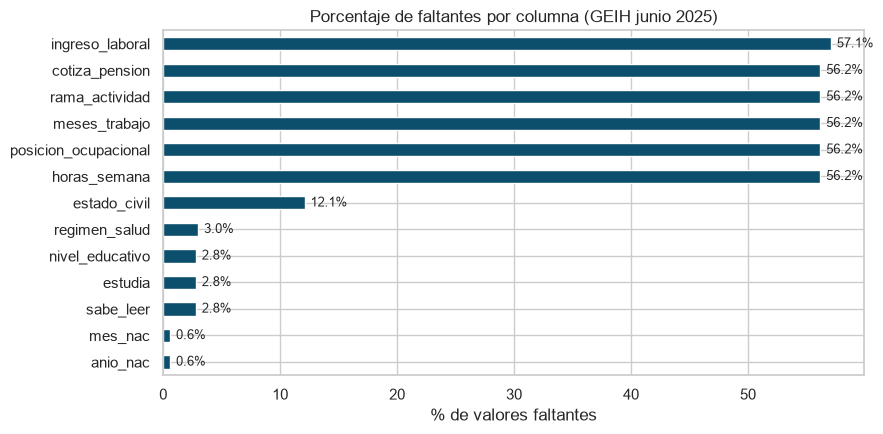

In [6]:
faltantes = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
faltantes = faltantes[faltantes > 0]

fig, ax = plt.subplots(figsize=(9, 4.5))
faltantes.plot.barh(ax=ax, color=AZUL)
ax.invert_yaxis()
ax.set_xlabel("% de valores faltantes")
ax.set_title("Porcentaje de faltantes por columna (GEIH junio 2025)")
for i, v in enumerate(faltantes):
    ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()

### Faltante estructural vs. faltante real

Mira el grafico: las seis variables de *Ocupados* tienen ~56% de faltantes. **Eso no es un problema de calidad**: el 56% de las personas no estan ocupadas, asi que no tienen ingreso laboral ni horas ni posicion ocupacional. Es un faltante **estructural**: la pregunta no aplica.

La forma de comprobarlo es cruzar el faltante con la variable que gobierna el flujo del cuestionario. Si el nulo en `nivel_educativo` es estructural, debe concentrarse en los ninos de 0 a 2 anos (a los que no se les pregunta). Si el nulo en `estado_civil` es estructural, debe concentrarse en los menores de 10.

In [7]:
print("Edad de quienes tienen nivel_educativo nulo:")
print(df.loc[df.nivel_educativo.isna(), "edad"].describe()[["count", "min", "max"]])
print()
print("Edad de quienes tienen estado_civil nulo:")
print(df.loc[df.estado_civil.isna(), "edad"].describe()[["count", "min", "max"]])

Edad de quienes tienen nivel_educativo nulo:
count   1,903.00
min         0.00
max         2.00
Name: edad, dtype: float64

Edad de quienes tienen estado_civil nulo:
count   8,235.00
min         0.00
max         9.00
Name: edad, dtype: float64


Confirmado: los nulos de `nivel_educativo` son **todos** ninos de 0 a 2 anos y los de `estado_civil` son **todos** menores de 10. Ninguno de esos nulos se debe imputar: imputarle un nivel educativo a un bebe seria *inventar* datos.

Ahora la otra cara. Entre los **ocupados** (las personas que si tienen posicion ocupacional), cuantos no tienen ingreso? Y de que tipo son? Aqui la trampa es mas fina: un **trabajador familiar sin remuneracion** (codigo 6) trabaja pero por definicion no recibe ingreso, asi que su nulo vuelve a ser estructural. Solo los demas son faltantes **reales**: la pregunta aplicaba y no hubo respuesta.

In [8]:
es_ocupado = df.posicion_ocupacional.notna()
sin_ingreso = es_ocupado & df.ingreso_laboral.isna()

print(f"Ocupados: {es_ocupado.sum():,}")
print(f"Ocupados sin ingreso reportado: {sin_ingreso.sum():,}  ({sin_ingreso.sum()/es_ocupado.sum():.1%})")
print("\nDe que posicion ocupacional son? (codigo 6 = trabajador familiar sin remuneracion)")
print(df.loc[sin_ingreso, "posicion_ocupacional"].value_counts())

Ocupados: 29,706
Ocupados sin ingreso reportado: 614  (2.1%)

De que posicion ocupacional son? (codigo 6 = trabajador familiar sin remuneracion)
posicion_ocupacional
6.00    455
4.00     73
1.00     41
5.00     32
2.00     13
Name: count, dtype: int64


<div style="background:#E1E8F8;border-left:6px solid #2B4C9B;border-radius:8px;padding:14px 18px;margin:16px 0;">
  <b style="color:#1B3268;">La pregunta que define todo</b><br>
  <span style="color:#1A1A1A;font-size:14px;">Para cada columna con nulos pregunta: <b>aplicaba la pregunta a esta persona?</b> Si no aplicaba, el nulo es informacion (significa "no corresponde") y se deja o se reemplaza por una categoria explicita como <code>"No aplica"</code>. Si aplicaba, el nulo es un hueco y ahi si entran las tecnicas de imputacion de la Seccion 5. En nuestro caso: de los 614 ocupados sin ingreso, 455 son familiares sin remuneracion (estructural) y <b>159 son faltantes reales</b>.</span>
</div>

### Valores centinela: el `9` que no es un nueve

En muchas encuestas, "no sabe / no informa" se codifica con `9`, `99` o `9999`. Si dejas ese `9` en `afiliado_salud` (donde 1 = si, 2 = no), cualquier conteo o promedio lo tratara como una tercera categoria valida, o peor, como el numero nueve. El primer paso es **contarlos**; el segundo, **convertirlos a `NaN`** para que pandas los excluya solo.

Antes de reemplazar, verifica siempre que el codigo centinela **no sea un valor legitimo** en esa columna: en `nivel_educativo`, `9` significa "tecnologica" y el "no sabe" es `99` (que en este mes no aparece); en `posicion_ocupacional`, `9` es "otro". Verificalo con `value_counts()` antes de reemplazar.

In [9]:
centinelas = {"afiliado_salud": [9], "regimen_salud": [9], "campesino": [9], "nivel_educativo": [99]}

for col, codigos in centinelas.items():
    n = df[col].isin(codigos).sum()
    print(f"{col:<18} codigos {codigos}: {n:,} registros ({n/len(df):.2%})")

afiliado_salud     codigos [9]: 16 registros (0.02%)
regimen_salud      codigos [9]: 25 registros (0.04%)
campesino          codigos [9]: 142 registros (0.21%)
nivel_educativo    codigos [99]: 0 registros (0.00%)


In [10]:
for col, codigos in centinelas.items():
    df[col] = df[col].replace(codigos, np.nan)

print("Valores unicos tras limpiar centinelas:")
for col in centinelas:
    print(f"  {col:<18}", sorted(df[col].dropna().unique()))

Valores unicos tras limpiar centinelas:
  afiliado_salud     [np.float64(1.0), np.float64(2.0)]
  regimen_salud      [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  campesino          [np.float64(1.0), np.float64(2.0)]
  nivel_educativo    [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0)]


### De codigos a categorias

Ahora convertimos los codigos en etiquetas. Tres razones: (1) un `value_counts()` pasa a leerse sin diccionario, (2) pandas deja de tentarte a promediar un codigo, (3) el tipo `category` ocupa menos memoria y hace los `groupby` mas rapidos.

Usamos `.map()` con un diccionario por columna. Lo que no este en el diccionario se vuelve `NaN`, asi que es tambien una forma de detectar **codigos fuera de rango**: compara los nulos antes y despues.

In [11]:
etiquetas = {
    "sexo":           {1: "Hombre", 2: "Mujer"},
    "clase":          {1: "Cabecera", 2: "Rural"},
    "afiliado_salud": {1: "Si", 2: "No"},
    "regimen_salud":  {1: "Contributivo", 2: "Especial", 3: "Subsidiado"},
    "sabe_leer":      {1: "Si", 2: "No"},
    "estudia":        {1: "Si", 2: "No"},
    "campesino":      {1: "Si", 2: "No"},
    "padre_en_hogar": {1: "Vive en el hogar", 2: "Vive en otro hogar", 3: "Fallecido"},
    "madre_en_hogar": {1: "Vive en el hogar", 2: "Vive en otro hogar", 3: "Fallecida"},
    "etnia":          {1: "Indigena", 2: "Gitano", 3: "Raizal", 4: "Palenquero", 5: "Negro/afro", 6: "Ninguno"},
    "estado_civil":   {1: "Union libre <2a", 2: "Union libre >=2a", 3: "Casado(a)", 4: "Separado(a)", 5: "Viudo(a)", 6: "Soltero(a)"},
    "nivel_educativo":{1: "Ninguno", 2: "Preescolar", 3: "Primaria", 4: "Secundaria", 5: "Media academica", 6: "Media tecnica",
                       7: "Normalista", 8: "Tecnica", 9: "Tecnologica", 10: "Universitaria", 11: "Especializacion", 12: "Maestria", 13: "Doctorado"},
    "posicion_ocupacional": {1: "Empleado particular", 2: "Empleado del gobierno", 3: "Empleado domestico", 4: "Cuenta propia",
                             5: "Patron/empleador", 6: "Familiar sin remuneracion", 7: "Sin remuneracion otras empresas", 8: "Jornalero/peon", 9: "Otro"},
    "cotiza_pension": {1: "Si", 2: "No", 3: "Pensionado"},
}
# parentesco: solo los tres codigos principales tienen interpretacion directa; el resto se agrupa
etiquetas["parentesco"] = {1: "Jefe(a)", 2: "Pareja", 3: "Hijo(a)", **{k: "Otro" for k in range(4, 14)}}

nulos_antes = df.isna().sum()
for col, mapa in etiquetas.items():
    df[col] = df[col].map(mapa).astype("category")
nulos_despues = df.isna().sum()

cambios = (nulos_despues - nulos_antes)
print("Nuevos nulos creados por codigos fuera del diccionario:")
print(cambios[cambios > 0] if (cambios > 0).any() else "  ninguno: todos los codigos estaban en el diccionario")
df[["sexo", "edad", "nivel_educativo", "posicion_ocupacional", "ingreso_laboral"]].head(8)

Nuevos nulos creados por codigos fuera del diccionario:
  ninguno: todos los codigos estaban en el diccionario


,sexo,edad,nivel_educativo,posicion_ocupacional,ingreso_laboral
0,Mujer,66,Media academica,Cuenta propia,"950,000.00"
1,Hombre,32,Media academica,Familiar sin remuneracion,NaN
2,Hombre,76,Primaria,Cuenta propia,"700,000.00"
3,Hombre,49,Ninguno,NaN,NaN
4,Mujer,52,Ninguno,Cuenta propia,"2,000,000.00"
5,Hombre,68,Ninguno,Cuenta propia,"600,000.00"
6,Hombre,63,Media academica,Cuenta propia,"1,300,000.00"
7,Hombre,72,Ninguno,NaN,NaN


El nivel educativo es una categoria **ordinal**: Primaria < Secundaria < Universitaria. Si le decimos a pandas ese orden, `sort_values`, los graficos y las comparaciones `<` lo respetaran. Lo mismo aplica a cualquier escala tipo Likert.

In [12]:
orden_educ = ["Ninguno", "Preescolar", "Primaria", "Secundaria", "Media academica", "Media tecnica", "Normalista",
              "Tecnica", "Tecnologica", "Universitaria", "Especializacion", "Maestria", "Doctorado"]
df["nivel_educativo"] = pd.Categorical(df["nivel_educativo"], categories=orden_educ, ordered=True)

df["nivel_educativo"].value_counts(sort=False)

nivel_educativo
Ninguno             3341
Preescolar          1574
Primaria           16273
Secundaria          9883
Media academica    16189
Media tecnica       1349
Normalista           114
Tecnica             4443
Tecnologica         2018
Universitaria       8663
Especializacion     1411
Maestria             607
Doctorado             88
Name: count, dtype: int64

Por ultimo, el departamento. `dpto` es un codigo, no una cantidad: `76` (Valle) no es "mas" que `5` (Antioquia). Lo mapeamos a nombre y verificamos que ningun codigo quede sin etiqueta.

In [13]:
departamentos = {5: "Antioquia", 8: "Atlantico", 11: "Bogota D.C.", 13: "Bolivar", 15: "Boyaca", 17: "Caldas", 18: "Caqueta",
    19: "Cauca", 20: "Cesar", 23: "Cordoba", 25: "Cundinamarca", 27: "Choco", 41: "Huila", 44: "La Guajira", 47: "Magdalena",
    50: "Meta", 52: "Narino", 54: "Norte de Santander", 63: "Quindio", 66: "Risaralda", 68: "Santander", 70: "Sucre",
    73: "Tolima", 76: "Valle del Cauca", 81: "Arauca", 85: "Casanare", 86: "Putumayo", 88: "San Andres", 91: "Amazonas",
    94: "Guainia", 95: "Guaviare", 97: "Vaupes", 99: "Vichada"}

sin_nombre = set(df.dpto.unique()) - set(departamentos)
print("Codigos de departamento sin nombre:", sin_nombre or "ninguno")
df["departamento"] = df.dpto.map(departamentos).astype("category")
df.departamento.value_counts().head()

Codigos de departamento sin nombre: ninguno


departamento
Antioquia          3832
Valle del Cauca    3595
Caldas             3301
Santander          3238
Risaralda          3136
Name: count, dtype: int64

### El archivo despues del diagnostico

Un vistazo a `describe()` solo sobre las numericas que de verdad son cantidades. Fijate en los maximos: un ingreso de **100 millones**, **130 horas** a la semana, **850 meses** (70 anos) en el mismo trabajo. Son los candidatos a atipicos de la Seccion 4.

In [14]:
numericas = ["edad", "ingreso_laboral", "horas_semana", "meses_trabajo", "fex"]
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,"67,856.00",36.63,22.32,0.00,18.00,34.00,54.00,103.00
ingreso_laboral,"29,092.00","1,791,374.14","2,462,586.36",0.00,"800,000.00","1,423,500.00","2,000,000.00","100,000,000.00"
horas_semana,"29,706.00",43.82,12.66,1.00,40.00,46.00,48.00,130.00
meses_trabajo,"29,706.00",84.39,109.90,0.00,12.00,36.00,120.00,850.00
fex,"67,856.00",766.99,"1,096.06",9.56,157.90,312.48,935.37,"17,668.83"


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 3</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Duplicados e inconsistencias logicas</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Registros que no deberian existir y valores que se contradicen entre si.</div>
</div>

La GEIH llega del DANE sin duplicados: la llave `(directorio, secuencia_p, orden)` identifica a cada persona exactamente una vez. Pero en el mundo real los datos pasan por exportaciones, uniones y copias, y los duplicados aparecen. Para que practiques con un caso realista vamos a **ensuciar una copia a proposito**, de forma explicita y con semilla, de modo que sepamos exactamente que metimos y podamos comprobar que lo sacamos.

Fijate en la diferencia entre dos tipos de duplicado:

- **Duplicado exacto**: la fila completa se repite. `df.duplicated()` lo encuentra.
- **Duplicado de llave**: la misma persona aparece dos veces pero con alguna columna distinta (por ejemplo, una correccion posterior). Solo lo encuentras con `duplicated(subset=llave)`, y decidir cual conservar requiere una regla.

In [15]:
rng = np.random.default_rng(42)
llave = ["directorio", "secuencia_p", "orden"]

# 1) 300 duplicados exactos
dup_exactos = df.sample(300, random_state=1)
# 2) 150 duplicados de llave con el ingreso alterado (simula una "correccion" que se cargo sin borrar la anterior)
dup_llave = df[df.ingreso_laboral > 0].sample(150, random_state=2).copy()
dup_llave["ingreso_laboral"] = dup_llave["ingreso_laboral"] * 1.10

sucio = pd.concat([df, dup_exactos, dup_llave], ignore_index=True)
print("Filas originales:", f"{len(df):,}", "| filas del archivo sucio:", f"{len(sucio):,}")
print("Duplicados exactos:", sucio.duplicated().sum())
print("Duplicados de llave:", sucio.duplicated(subset=llave).sum())

Filas originales: 67,856 | filas del archivo sucio: 68,306
Duplicados exactos: 300
Duplicados de llave: 450


Fijate en los numeros: `duplicated()` cuenta 300 exactos, pero `duplicated(subset=llave)` cuenta 450, porque los 300 exactos **tambien** repiten la llave. Los de llave son 450 - 300 = 150.

Los duplicados exactos se eliminan sin dudar. Para los de llave hay que **decidir cual conservar**: aqui asumimos que la version con mayor ingreso es la correccion mas reciente (la regla la define el negocio, no pandas). Ordenamos para que esa quede de primera y usamos `keep="first"`.

In [16]:
limpio = sucio.drop_duplicates()                                         # exactos
limpio = (limpio.sort_values(llave + ["ingreso_laboral"], ascending=[True, True, True, False])
                .drop_duplicates(subset=llave, keep="first")              # de llave
                .sort_index())

print("Filas tras eliminar duplicados:", f"{len(limpio):,}")
print("Coincide con el original:", len(limpio) == len(df))
print("Llave unica:", not limpio.duplicated(subset=llave).any())

Filas tras eliminar duplicados: 67,856
Coincide con el original: True
Llave unica: True


### Reglas de validacion: cuando los datos se contradicen

Un registro puede no estar duplicado, no tener nulos y aun asi ser imposible. La herramienta es una **lista de reglas** que el dato debe cumplir, escritas como condiciones booleanas. Cada regla devuelve cuantas filas la violan; asi tienes un reporte de calidad, no una opinion.

Escribe reglas que vengan del **conocimiento del dominio**, no del dataset:

- La edad debe ser consistente con el ano de nacimiento (diferencia de a lo sumo un ano, segun si ya cumplio).
- Nadie trabaja mas de 168 horas a la semana (y mas de 84 ya es sospechoso).
- La antiguedad en el trabajo no puede superar los anos de vida laboral (edad menos 10 anos, siendo generosos).
- Un menor de 15 anos no deberia tener doctorado.
- Quien no esta afiliado a salud no deberia tener regimen.

In [17]:
def validar(d):
    anio_ref = 2025
    reglas = {
        "edad inconsistente con anio de nacimiento": ((anio_ref - d.anio_nac) - d.edad).abs() > 1,
        "horas_semana > 168 (imposible)":              d.horas_semana > 168,
        "horas_semana > 84 (sospechoso)":              d.horas_semana > 84,
        "meses_trabajo supera la vida laboral":        d.meses_trabajo > (d.edad - 10) * 12,
        "menor de 15 con posgrado":                    (d.edad < 15) & d.nivel_educativo.isin(["Especializacion", "Maestria", "Doctorado"]),
        "menor de 10 ocupado":                         (d.edad < 10) & d.posicion_ocupacional.notna(),
        "no afiliado pero con regimen":                (d.afiliado_salud == "No") & d.regimen_salud.notna(),
        "ingreso negativo":                            d.ingreso_laboral < 0,
        "factor de expansion <= 0":                    d.fex <= 0,
    }
    reporte = pd.DataFrame({"violaciones": {k: int(v.sum()) for k, v in reglas.items()}})
    reporte["%"] = (reporte.violaciones / len(d) * 100).round(3)
    return reporte, reglas

reporte, reglas = validar(limpio)
reporte

,violaciones,%
edad inconsistente con anio de nacimiento,0,0.00
horas_semana > 168 (imposible),0,0.00
horas_semana > 84 (sospechoso),112,0.17
meses_trabajo supera la vida laboral,5,0.01
menor de 15 con posgrado,0,0.00
menor de 10 ocupado,0,0.00
no afiliado pero con regimen,0,0.00
ingreso negativo,0,0.00
factor de expansion <= 0,0,0.00


Dos reglas se violan. Inspecciona los casos antes de decidir: **mirar los registros** siempre va antes de borrarlos o corregirlos.

In [18]:
cols_ver = ["edad", "sexo", "posicion_ocupacional", "horas_semana", "meses_trabajo", "ingreso_laboral"]
print("Antiguedad mayor que la vida laboral:")
display(limpio.loc[reglas["meses_trabajo supera la vida laboral"], cols_ver].head(8))
print("\nMas de 84 horas a la semana:")
display(limpio.loc[reglas["horas_semana > 84 (sospechoso)"], cols_ver].sort_values("horas_semana", ascending=False).head(8))

Antiguedad mayor que la vida laboral:


,edad,sexo,posicion_ocupacional,horas_semana,meses_trabajo,ingreso_laboral
19611,59,Mujer,Cuenta propia,24.00,590.00,"320,000.00"
39025,43,Hombre,Cuenta propia,45.00,400.00,"400,000.00"
43403,38,Hombre,Cuenta propia,60.00,344.00,"1,450,000.00"
51476,80,Mujer,Cuenta propia,30.00,850.00,"294,000.00"
66875,21,Hombre,Cuenta propia,35.00,140.00,"120,000.00"



Mas de 84 horas a la semana:


,edad,sexo,posicion_ocupacional,horas_semana,meses_trabajo,ingreso_laboral
42218,59,Hombre,Cuenta propia,130.00,60.00,"900,000.00"
41991,37,Hombre,Empleado del gobierno,130.00,228.00,"3,500,000.00"
23314,48,Mujer,Cuenta propia,130.00,27.00,"1,000,000.00"
38102,50,Hombre,Empleado particular,130.00,12.00,"2,000,000.00"
3490,43,Hombre,Patron/empleador,120.00,240.00,"80,000,000.00"
45415,23,Mujer,Empleado domestico,120.00,12.00,"1,960,000.00"
45020,50,Hombre,Cuenta propia,119.00,60.00,"500,000.00"
23322,59,Hombre,Cuenta propia,115.00,60.00,"1,100,000.00"


<div style="background:#E1E8F8;border-left:6px solid #2B4C9B;border-radius:8px;padding:14px 18px;margin:16px 0;">
  <b style="color:#1B3268;">Que hacer con una inconsistencia</b><br>
  <span style="color:#1A1A1A;font-size:14px;">Tienes cuatro opciones y ninguna es "borrar sin mirar": (1) <b>corregir</b> si la regla te dice el valor correcto (por ejemplo recalcular la edad desde el ano de nacimiento), (2) <b>anular</b> el valor dudoso (ponerlo en <code>NaN</code>) y tratarlo como faltante, (3) <b>marcar</b> la fila con una columna bandera y seguir, (4) <b>eliminar</b> la fila solo si la inconsistencia invalida todo el registro. Para las horas y la antiguedad vamos a anular y marcar; lo retomamos en la Seccion 4.</span>
</div>

In [19]:
df = limpio.copy()
df["flag_horas_sospechosas"] = reglas["horas_semana > 84 (sospechoso)"]
df["flag_antiguedad_imposible"] = reglas["meses_trabajo supera la vida laboral"]
df.loc[df.flag_antiguedad_imposible, "meses_trabajo"] = np.nan

print("Marcadas por horas:", df.flag_horas_sospechosas.sum(), "| anuladas por antiguedad:", df.flag_antiguedad_imposible.sum())

Marcadas por horas: 112 | anuladas por antiguedad: 5


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 4</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Datos atipicos</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Valores que se salen del patron. Detectarlos es facil; decidir que hacer con ellos es el trabajo.</div>
</div>

Un **dato atipico** (*outlier*) es una observacion que se aleja mucho del resto. Puede ser un **error** (alguien escribio un cero de mas), un **caso real pero raro** (un gerente que gana 100 millones) o una **senal** de que la variable tiene una distribucion con cola larga (el ingreso siempre la tiene). El metodo de deteccion no distingue entre los tres; tu si tienes que hacerlo.

Trabajamos con el ingreso laboral de los ocupados, que es el ejemplo perfecto: la mayoria gana entre uno y dos salarios minimos y una minoria gana decenas de millones. Empieza **siempre** por mirar la distribucion.

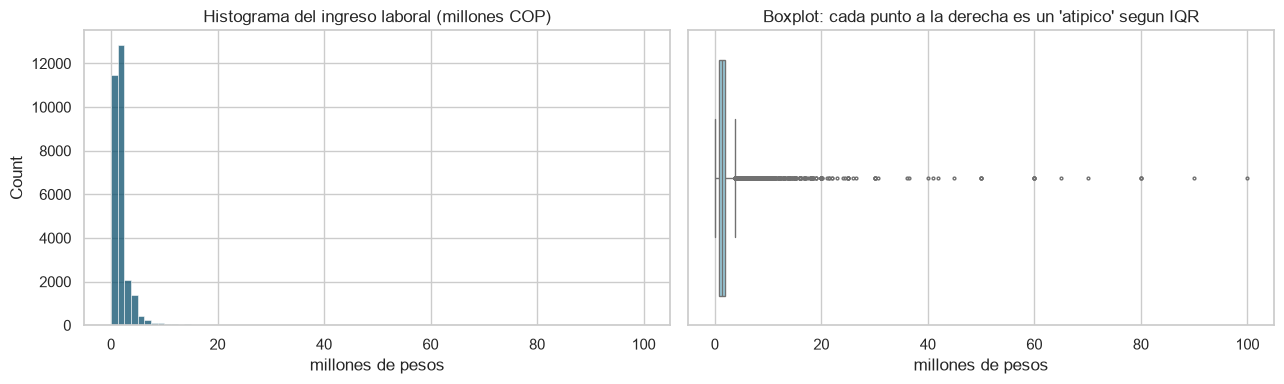

Media: 1,804,102 | Mediana: 1,423,500 | Maximo: 100,000,000
Asimetria (skew): 14.44   (0 = simetrica; > 1 = cola derecha fuerte)


In [20]:
ocupados = df[df.posicion_ocupacional.notna() & df.ingreso_laboral.notna() & (df.ingreso_laboral > 0)].copy()
ing = ocupados.ingreso_laboral

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(ing / 1e6, bins=80, ax=axes[0], color=AZUL)
axes[0].set_title("Histograma del ingreso laboral (millones COP)"); axes[0].set_xlabel("millones de pesos")
sns.boxplot(x=ing / 1e6, ax=axes[1], color=CELESTE, fliersize=2)
axes[1].set_title("Boxplot: cada punto a la derecha es un 'atipico' segun IQR"); axes[1].set_xlabel("millones de pesos")
plt.tight_layout(); plt.show()

print(f"Media: {ing.mean():,.0f} | Mediana: {ing.median():,.0f} | Maximo: {ing.max():,.0f}")
print(f"Asimetria (skew): {ing.skew():.2f}   (0 = simetrica; > 1 = cola derecha fuerte)")

La media (1,8 millones) esta muy por encima de la mediana (1,4 millones): la cola derecha la arrastra. Esa brecha es la primera pista de que hay valores extremos con peso.

### Metodo 1: rango intercuartilico (IQR)

Es la regla del boxplot. Se calcula `Q1` (percentil 25), `Q3` (percentil 75) y `IQR = Q3 - Q1`. Todo lo que queda fuera de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` es atipico. No asume ninguna distribucion y no le afectan los extremos, porque los cuartiles no se mueven por un valor gigante. El `1.5` es convencion; con `3` obtienes solo los "extremos".

In [21]:
def atipicos_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - k * iqr, q3 + k * iqr
    return (s < lim_inf) | (s > lim_sup), (lim_inf, lim_sup)

mask_iqr, (li, ls) = atipicos_iqr(ing)
print(f"Limites IQR (k=1.5): [{li:,.0f} ; {ls:,.0f}]")
print(f"Atipicos: {mask_iqr.sum():,} de {len(ing):,} ({mask_iqr.mean():.1%})")

Limites IQR (k=1.5): [-1,000,000 ; 3,800,000]
Atipicos: 2,397 de 28,902 (8.3%)


### Metodo 2: z-score

Mide a cuantas desviaciones estandar esta cada valor de la media: `z = (x - media) / desv`. Se considera atipico si `|z| > 3`. Es el metodo clasico, pero tiene un defecto serio: **la media y la desviacion estandar se calculan con los mismos atipicos que intentas detectar**. Un valor de 100 millones infla la desviacion y hace que otros valores extremos parezcan normales. Ademas, supone que la variable se parece a una campana, y el ingreso no se parece en nada.

In [22]:
def atipicos_z(s, umbral=3):
    z = (s - s.mean()) / s.std()
    return z.abs() > umbral, z

mask_z, z = atipicos_z(ing)
print(f"Atipicos z-score (|z| > 3): {mask_z.sum():,} ({mask_z.mean():.2%})")
print(f"Un ingreso de 5 millones tiene z = {((5e6 - ing.mean()) / ing.std()):.2f}  -> 'normal' segun este metodo")

Atipicos z-score (|z| > 3): 306 (1.06%)
Un ingreso de 5 millones tiene z = 1.30  -> 'normal' segun este metodo


### Metodo 3: z-score robusto (MAD)

Arregla el defecto anterior reemplazando la media por la **mediana** y la desviacion estandar por la **desviacion absoluta mediana** (MAD): la mediana de `|x - mediana|`. Ninguna de las dos se mueve por valores extremos. La formula es `z_rob = 0.6745 * (x - mediana) / MAD` (la constante hace que sea comparable con el z normal si los datos fueran gaussianos). Umbral habitual: `3.5`.

In [23]:
def atipicos_mad(s, umbral=3.5):
    mediana = s.median()
    mad = (s - mediana).abs().median()
    z_rob = 0.6745 * (s - mediana) / mad
    return z_rob.abs() > umbral, z_rob

mask_mad, z_rob = atipicos_mad(ing)
print(f"Atipicos z robusto (|z| > 3.5): {mask_mad.sum():,} ({mask_mad.mean():.2%})")

Atipicos z robusto (|z| > 3.5): 1,720 (5.95%)


### Los tres metodos no coinciden, y eso es normal

Compara: el z-score clasico marca muy pocos porque los propios extremos lo "anestesian"; IQR y MAD marcan muchos mas porque la distribucion tiene cola larga. **Ningun metodo es "el correcto"**: cada uno responde a una definicion distinta de "lejos". Lo que si es incorrecto es aplicar uno sin saber que supone.

In [24]:
comparacion = pd.DataFrame({
    "IQR (k=1.5)":       mask_iqr,
    "z-score (|z|>3)":   mask_z,
    "z robusto (>3.5)":  mask_mad,
})
resumen = pd.DataFrame({
    "n_atipicos": comparacion.sum(),
    "% del total": (comparacion.mean() * 100).round(2),
    "ingreso minimo marcado": [ing[m].min() for m in comparacion.values.T],
})
display(resumen)

print("Coinciden los tres metodos en:", (comparacion.all(axis=1)).sum(), "registros")
print("Marcado por al menos uno:     ", (comparacion.any(axis=1)).sum(), "registros")

,n_atipicos,% del total,ingreso minimo marcado
IQR (k=1.5),2397,8.29,"3,820,000.00"
z-score (|z|>3),306,1.06,"9,223,500.00"
z robusto (>3.5),1720,5.95,"4,450,000.00"


Coinciden los tres metodos en: 306 registros
Marcado por al menos uno:      2397 registros


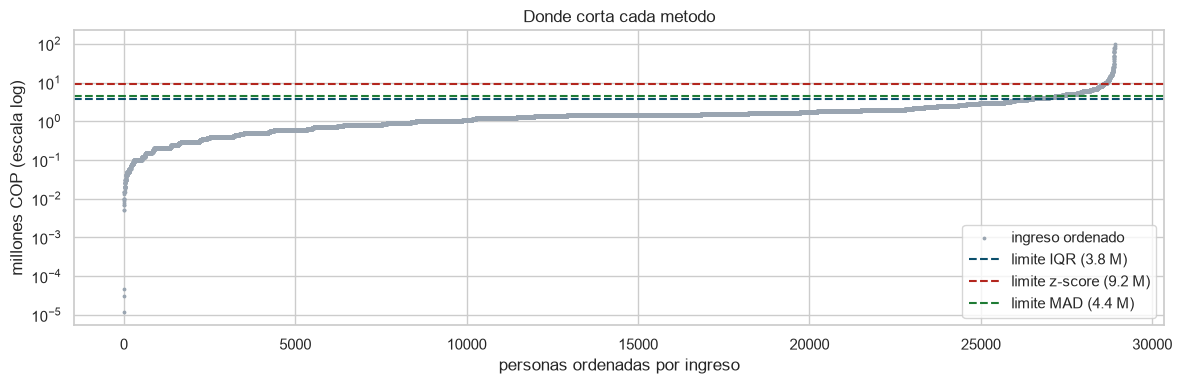

In [25]:
fig, ax = plt.subplots(figsize=(12, 4))
orden = ing.sort_values().reset_index(drop=True)
ax.scatter(orden.index, orden / 1e6, s=3, color=GRIS, label="ingreso ordenado")
ax.axhline(ls / 1e6, color=AZUL, ls="--", label=f"limite IQR ({ls/1e6:.1f} M)")
ax.axhline((ing.mean() + 3 * ing.std()) / 1e6, color=ROJO, ls="--", label=f"limite z-score ({(ing.mean()+3*ing.std())/1e6:.1f} M)")
lim_mad = ing.median() + 3.5 * (ing - ing.median()).abs().median() / 0.6745
ax.axhline(lim_mad / 1e6, color="#1E7B34", ls="--", label=f"limite MAD ({lim_mad/1e6:.1f} M)")
ax.set_yscale("log"); ax.set_ylabel("millones COP (escala log)"); ax.set_xlabel("personas ordenadas por ingreso")
ax.set_title("Donde corta cada metodo"); ax.legend()
plt.tight_layout(); plt.show()

### Atipico o error? Mira el contexto

Antes de decidir, cruza los valores extremos con otras variables. Un ingreso de 30 millones en un **patron o empleador** con **maestria** es plausible; el mismo ingreso en un **jornalero** con **primaria** merece sospecha. Los atipicos se juzgan **en contexto**, nunca en una sola columna.

In [26]:
extremos = ocupados.loc[mask_mad].sort_values("ingreso_laboral", ascending=False)
extremos[["ingreso_laboral", "posicion_ocupacional", "nivel_educativo", "edad", "horas_semana", "departamento"]].head(10)

,ingreso_laboral,posicion_ocupacional,nivel_educativo,edad,horas_semana,departamento
19362,"100,000,000.00",Patron/empleador,Universitaria,36,10.00,Meta
11677,"90,000,000.00",Patron/empleador,Universitaria,34,46.00,Tolima
20394,"80,000,000.00",Patron/empleador,Universitaria,72,40.00,Santander
3490,"80,000,000.00",Patron/empleador,Tecnica,43,120.00,Caldas
40515,"80,000,000.00",Empleado particular,Universitaria,30,48.00,Bogota D.C.
47462,"70,000,000.00",Patron/empleador,Universitaria,46,48.00,Sucre
24085,"65,000,000.00",Patron/empleador,Universitaria,60,48.00,Antioquia
8714,"60,000,000.00",Patron/empleador,Universitaria,24,25.00,Narino
64654,"60,000,000.00",Patron/empleador,Universitaria,46,40.00,Tolima
39224,"60,000,000.00",Cuenta propia,Universitaria,59,50.00,Antioquia


In [27]:
# Composicion de los atipicos vs. el resto: que posicion ocupacional tienen
tabla = pd.crosstab(ocupados.posicion_ocupacional, mask_mad.map({True: "atipico", False: "normal"}), normalize="columns") * 100
tabla.round(1).sort_values("atipico", ascending=False)

ingreso_laboral,atipico,normal
posicion_ocupacional,,
Empleado del gobierno,34.20,3.60
Empleado particular,33.60,43.90
Cuenta propia,23.30,44.40
Patron/empleador,8.50,1.70
Empleado domestico,0.20,3.70
Sin remuneracion otras empresas,0.10,2.70
Jornalero/peon,0.00,0.00


### Cuatro tratamientos posibles

| Tratamiento | Que hace | Cuando usarlo |
|---|---|---|
| **Eliminar** | Borra las filas | Solo si estas seguro de que son errores. Con ingresos, casi nunca: perderias justamente a los que mas ganan y sesgarias todo. |
| **Winsorizar** (recortar) | Reemplaza los valores por encima del percentil 99 por el valor del percentil 99 | Cuando quieres limitar la influencia de los extremos sin perder las filas. Estandar en analisis de ingresos. |
| **Transformar** | Aplica logaritmo u otra funcion que comprime la cola | Cuando la variable es multiplicativa por naturaleza (ingresos, precios, poblacion). Lo vemos en la Seccion 7. |
| **Marcar** | Crea una columna booleana y no toca el valor | Cuando vas a dejar que el analisis posterior decida. La opcion mas honesta cuando hay duda. |

Veamos el efecto de cada uno sobre la media y la mediana.

In [28]:
p01, p99 = ing.quantile([0.01, 0.99])

tratamientos = {
    "Original":                 ing,
    "Eliminar (MAD)":           ing[~mask_mad],
    "Winsorizar p1-p99":        ing.clip(lower=p01, upper=p99),
    "Log (log1p)":              np.log1p(ing),
}
efecto = pd.DataFrame({
    nombre: {"n": len(s), "media": s.mean(), "mediana": s.median(), "desv": s.std(), "max": s.max(), "skew": s.skew()}
    for nombre, s in tratamientos.items()
}).T
efecto

,n,media,mediana,desv,max,skew
Original,"28,902.00","1,804,102.46","1,423,500.00","2,467,139.47","100,000,000.00",14.44
Eliminar (MAD),"27,182.00","1,422,375.36","1,423,500.00","876,082.87","4,410,000.00",0.99
Winsorizar p1-p99,"28,902.00","1,724,466.06","1,423,500.00","1,530,834.81","9,500,000.00",2.58
Log (log1p),"28,902.00",14.03,14.17,0.89,18.42,-0.82


Lee la tabla fila a fila:

- **Eliminar** pierde ~1.700 personas y baja la media un 21%. Esas personas existen; borrarlas cambia la respuesta a "cuanto gana la gente".
- **Winsorizar** conserva todas las filas, acerca la media a la mediana y reduce la asimetria, pero sin anularla.
- **Log** es la unica que deja la asimetria cerca de cero: convierte la cola en una campana. El costo es que las unidades ya no son pesos (lo resolvemos en la Seccion 7).

Aplicamos la opcion de **marcar** + **winsorizar en una columna nueva**, que es la practica mas segura: el dato original sigue ahi.

In [29]:
df["flag_ingreso_atipico"] = False
df.loc[ocupados.index, "flag_ingreso_atipico"] = mask_mad
df["ingreso_wins"] = df.ingreso_laboral.clip(lower=p01, upper=p99)

df.loc[df.flag_ingreso_atipico, ["ingreso_laboral", "ingreso_wins", "posicion_ocupacional"]].head()

,ingreso_laboral,ingreso_wins,posicion_ocupacional
265,"5,000,000.00","5,000,000.00",Empleado del gobierno
406,"10,000,000.00","9,500,000.00",Patron/empleador
499,"5,000,000.00","5,000,000.00",Patron/empleador
609,"4,500,000.00","4,500,000.00",Patron/empleador
761,"6,400,000.00","6,400,000.00",Empleado del gobierno


<div style="background:#E6F4EA;border-left:6px solid #1E7B34;border-radius:8px;padding:14px 18px;margin:16px 0;">
  <b style="color:#145223;">Atipicos en variables de conteo</b><br>
  <span style="color:#1A1A1A;font-size:14px;">Para <code>horas_semana</code> el criterio no es estadistico sino <b>fisico</b>: ya marcamos las que superan 84 horas. Cuando exista un limite del mundo real, usalo en vez de IQR o z-score. La estadistica es el recurso cuando no tienes un limite de dominio.</span>
</div>

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 5</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Imputacion: un experimento controlado</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Borramos datos a proposito, los imputamos con seis metodos y medimos cual se acerca mas a la verdad.</div>
</div>

**Imputar** es rellenar un faltante con un valor estimado. El problema es que en un proyecto real nunca sabes si el valor que pusiste se parece al verdadero, porque el verdadero no existe. La unica forma de **aprender** que metodo funciona es montar un experimento donde si conoces la respuesta:

1. Tomar una tabla completa y guardarla como `original`.
2. **Borrar aleatoriamente** un porcentaje de valores en algunas columnas.
3. Imputar con cada metodo.
4. Comparar lo imputado con `original` **solo en las celdas que borramos**.

### Tres mecanismos de faltante

Por que falta un dato determina que metodos sirven:

| Mecanismo | Significa | Ejemplo en la GEIH | Consecuencia |
|---|---|---|---|
| **MCAR** (completamente al azar) | La probabilidad de faltar no depende de nada | Un error de digitacion que borra celdas al azar | Cualquier metodo razonable es insesgado; solo cambia la precision |
| **MAR** (al azar condicionado) | Depende de otras variables **observadas** | Los de mayor nivel educativo responden menos la pregunta de ingreso | La media simple se sesga; imputar **por grupo** o con modelos corrige |
| **MNAR** (no al azar) | Depende del propio valor faltante | Los que mas ganan no reportan precisamente porque ganan mucho | Ningun metodo lo corrige del todo; hay que modelar el mecanismo |

Vamos a simular **MCAR** en tres columnas y **MAR** en el ingreso, para ver como se comporta cada metodo en cada caso.

In [30]:
columnas_exp = ["ingreso_laboral", "horas_semana", "edad", "sexo", "nivel_educativo", "posicion_ocupacional", "clase", "departamento"]
base = df.loc[ocupados.index, columnas_exp].dropna().copy()
base["ingreso_laboral"] = base.ingreso_laboral.clip(upper=p99)   # trabajamos con la version winsorizada
original = base.copy()

print("Tabla del experimento:", base.shape, "| faltantes:", int(base.isna().sum().sum()))

Tabla del experimento: (28902, 8) | faltantes: 0


### Paso 1: borrar datos a proposito

`borrar_mcar` elige celdas al azar con probabilidad uniforme. `borrar_mar` hace que la probabilidad de borrar el ingreso **crezca con el nivel educativo**, de modo que los faltantes se concentran en quienes mas ganan. Fijate en que guardamos las **mascaras** (`mask_*`): son las coordenadas de lo que borramos, y las necesitamos para evaluar.

In [31]:
def borrar_mcar(d, col, frac, rng):
    """Pone NaN en una fraccion `frac` de la columna, elegida al azar."""
    idx = rng.choice(d.index, size=int(len(d) * frac), replace=False)
    mask = pd.Series(False, index=d.index); mask.loc[idx] = True
    d.loc[mask, col] = np.nan
    return mask

def borrar_mar(d, col, frac, rng, por="nivel_educativo"):
    """Pone NaN con probabilidad creciente segun el codigo ordinal de `por`."""
    nivel = d[por].cat.codes.astype(float)
    prob = (nivel - nivel.min() + 1) ** 2
    prob = prob / prob.sum()
    idx = rng.choice(d.index, size=int(len(d) * frac), replace=False, p=prob.values)
    mask = pd.Series(False, index=d.index); mask.loc[idx] = True
    d.loc[mask, col] = np.nan
    return mask

rng = np.random.default_rng(2025)
FRAC = 0.15

mcar = original.copy()
mask_mcar = {
    "ingreso_laboral": borrar_mcar(mcar, "ingreso_laboral", FRAC, rng),
    "horas_semana":    borrar_mcar(mcar, "horas_semana",    FRAC, rng),
    "nivel_educativo": borrar_mcar(mcar, "nivel_educativo", FRAC, rng),
}
mar = original.copy()
mask_mar = {"ingreso_laboral": borrar_mar(mar, "ingreso_laboral", FRAC, rng)}

print("MCAR - faltantes creados:"); print(mcar.isna().sum()[lambda s: s > 0])
print("\nMAR  - faltantes creados en ingreso:", mask_mar["ingreso_laboral"].sum())

MCAR - faltantes creados:
ingreso_laboral    4335
horas_semana       4335
nivel_educativo    4335
dtype: int64

MAR  - faltantes creados en ingreso: 4335


Verifiquemos que el borrado MAR de verdad sesga. Si los faltantes se concentran en los de mayor educacion, **el ingreso promedio de lo que quedo observado sera mas bajo que el real**. En MCAR, en cambio, deberia ser practicamente igual.

In [32]:
print(f"Media real del ingreso:                  {original.ingreso_laboral.mean():>12,.0f}")
print(f"Media de lo observado tras borrado MCAR: {mcar.ingreso_laboral.mean():>12,.0f}")
print(f"Media de lo observado tras borrado MAR:  {mar.ingreso_laboral.mean():>12,.0f}   <- sesgada hacia abajo")
print()
print("Proporcion de faltantes por nivel educativo (MAR):")
print(mar.groupby("nivel_educativo", observed=True).ingreso_laboral.apply(lambda s: s.isna().mean()).round(3))

Media real del ingreso:                     1,724,103
Media de lo observado tras borrado MCAR:    1,720,389
Media de lo observado tras borrado MAR:     1,612,056   <- sesgada hacia abajo

Proporcion de faltantes por nivel educativo (MAR):
nivel_educativo
Ninguno           0.00
Primaria          0.04
Secundaria        0.06
Media academica   0.09
Media tecnica     0.12
Normalista        0.14
Tecnica           0.21
Tecnologica       0.26
Universitaria     0.32
Especializacion   0.36
Maestria          0.41
Doctorado         0.46
Name: ingreso_laboral, dtype: float64


### Paso 2: las metricas de evaluacion

Para variables numericas comparamos el valor imputado con el real en las celdas borradas usando:

- **MAE** (error absoluto medio): en promedio, cuantos pesos nos equivocamos. Facil de leer.
- **RMSE** (raiz del error cuadratico medio): penaliza mas los errores grandes.
- **Sesgo de la media**: la media imputada menos la media real. Dice si el metodo *desplaza* la distribucion.
- **Razon de desviaciones**: `desv imputada / desv real`. Un metodo que rellena todo con la media **aplana** la distribucion (razon < 1), aunque su MAE sea bueno.

Para categoricas usamos **exactitud**: porcentaje de celdas donde acertamos la categoria.

In [33]:
def evaluar_numerica(imputado, col, mask):
    real, est = original.loc[mask, col], imputado.loc[mask, col]
    return {
        "MAE":        (est - real).abs().mean(),
        "RMSE":       np.sqrt(((est - real) ** 2).mean()),
        "sesgo_media": imputado[col].mean() - original[col].mean(),
        "razon_desv": imputado[col].std() / original[col].std(),
    }

def evaluar_categorica(imputado, col, mask):
    return {"exactitud": (imputado.loc[mask, col].astype(str) == original.loc[mask, col].astype(str)).mean()}

### Paso 3: los metodos

Cada metodo es una funcion que recibe la tabla con huecos y devuelve una copia rellena. Asi podemos recorrerlos en un bucle.

- **Media / mediana**: un solo numero para toda la columna. Rapido, pero aplana la varianza y, bajo MAR, hereda el sesgo.
- **Moda**: el equivalente para categoricas.
- **Por grupo**: la mediana (o la moda) calculada dentro de grupos definidos por otras columnas, por ejemplo `sexo x nivel_educativo x posicion_ocupacional`. Usa la informacion que si tenemos para estimar mejor. `groupby().transform()` devuelve una Serie del mismo tamano que la tabla, lista para `fillna`.
- **KNN**: busca los *k* registros mas parecidos (en las demas columnas numericas) y promedia su valor. Requiere escalar las variables primero (Seccion 7) porque mide distancias.
- **Iterativa** (MICE simplificado): modela cada columna con faltantes como funcion de las demas, imputa, y repite varias rondas hasta converger. Es el estado del arte entre los metodos "de libreria".

In [34]:
from sklearn.experimental import enable_iterative_imputer   # habilita IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler

NUM = ["ingreso_laboral", "horas_semana", "edad"]
GRUPO = ["sexo", "nivel_educativo", "posicion_ocupacional"]

def imp_media(d):
    out = d.copy(); out[NUM] = out[NUM].fillna(out[NUM].mean()); return out

def imp_mediana(d):
    out = d.copy(); out[NUM] = out[NUM].fillna(out[NUM].median()); return out

def imp_por_grupo(d):
    out = d.copy()
    for col in NUM:
        med_grupo = out.groupby(GRUPO, observed=True)[col].transform("median")
        out[col] = out[col].fillna(med_grupo).fillna(out[col].median())   # respaldo si el grupo quedo vacio
    return out

def imp_knn(d, k=10):
    out = d.copy()
    escalador = StandardScaler()
    X = escalador.fit_transform(out[NUM])                       # StandardScaler ignora NaN al ajustar
    X_imp = KNNImputer(n_neighbors=k).fit_transform(X)
    out[NUM] = escalador.inverse_transform(X_imp)
    return out

def imp_iterativa(d):
    out = d.copy()
    # codificamos las categoricas como numeros para que el modelo las use como predictores
    X = out[NUM].copy()
    for col in GRUPO:
        X[col + "_cod"] = out[col].cat.codes.replace(-1, np.nan)
    X_imp = IterativeImputer(max_iter=10, random_state=0).fit_transform(X)
    out[NUM] = X_imp[:, :len(NUM)]
    return out

metodos_num = {"Media": imp_media, "Mediana": imp_mediana, "Mediana por grupo": imp_por_grupo, "KNN (k=10)": imp_knn, "Iterativa": imp_iterativa}

### Paso 4: correr el experimento (MCAR)

Recorremos los metodos, imputamos la tabla con borrado MCAR y evaluamos el ingreso y las horas.

In [35]:
resultados = []
imputados_mcar = {}
for nombre, f in metodos_num.items():
    imp = f(mcar)
    imputados_mcar[nombre] = imp
    for col in ["ingreso_laboral", "horas_semana"]:
        m = evaluar_numerica(imp, col, mask_mcar[col])
        resultados.append({"metodo": nombre, "columna": col, **m})

res_mcar = pd.DataFrame(resultados).set_index(["columna", "metodo"])
res_mcar.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "sesgo_media": "{:,.0f}", "razon_desv": "{:.3f}"}) \
        .background_gradient(subset=["MAE", "RMSE"], cmap="Blues_r")

,,MAE,RMSE,sesgo_media,razon_desv
columna,metodo,,,,
ingreso_laboral,Media,"1,011,584","1,588,267","-3,713",0.916
horas_semana,Media,9,12,-0,0.922
ingreso_laboral,Mediana,"932,723","1,620,319","-48,244",0.918
horas_semana,Mediana,8,13,0,0.924
ingreso_laboral,Mediana por grupo,"711,374","1,265,998","-31,718",0.947
horas_semana,Mediana por grupo,8,12,0,0.930
ingreso_laboral,KNN (k=10),"1,157,603","1,685,406","26,891",0.934
horas_semana,KNN (k=10),10,13,-0,0.939
ingreso_laboral,Iterativa,"847,861","1,309,173","-2,498",0.948


Como leer la tabla (ingreso):

- **Media vs. mediana**: la mediana suele tener menor MAE porque la distribucion es sesgada: el "valor tipico" esta mas cerca de la mediana.
- **Por grupo** mejora el MAE porque el ingreso *depende* de sexo, educacion y posicion ocupacional. Usar esa informacion reduce el error.
- **KNN sale peor que la mediana**. No es un error: tal como lo configuramos, KNN mide la distancia entre personas usando solo `horas_semana` y `edad`, y esas dos variables predicen muy poco el ingreso. Un vecino "cercano" en horas y edad puede ganar diez veces mas. KNN es tan bueno como las variables con las que mide distancias.
- **La iterativa** si usa las categoricas (las codificamos como numeros para el modelo) y por eso se acerca a la imputacion por grupo.
- Mira la columna `razon_desv`: todos los metodos que imputan un "valor esperado" **encogen la varianza** (la razon queda por debajo de 1). Es el precio de imputar con promedios: la tabla imputada es mas "plana" que la realidad.
- El **sesgo de la media** bajo MCAR es pequeno para todos: como el borrado fue aleatorio, no hay sesgo que corregir.

Veamoslo en un grafico: la distribucion real de los valores borrados contra lo que puso cada metodo.

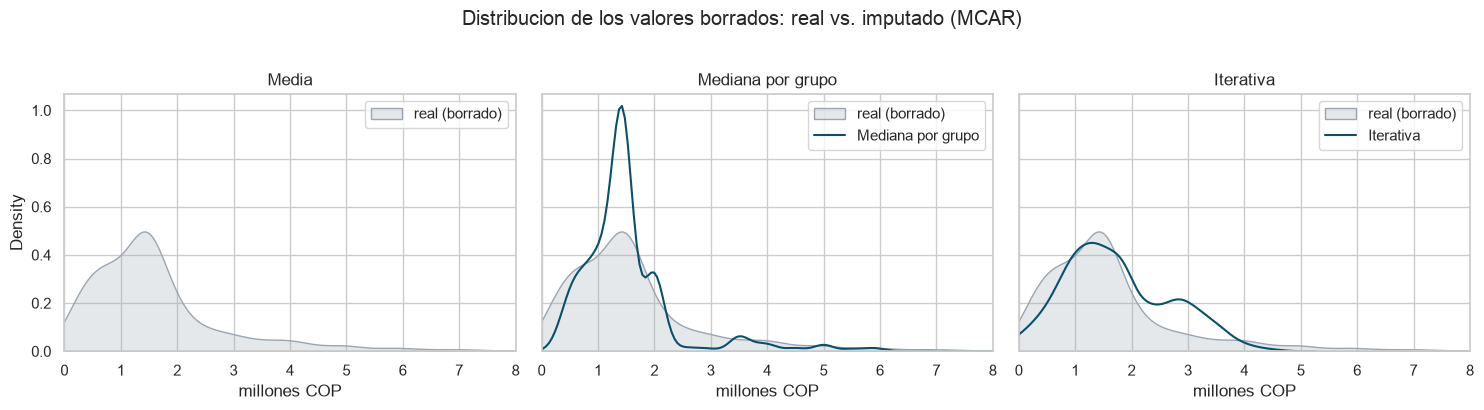

In [36]:
m = mask_mcar["ingreso_laboral"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, nombre in zip(axes, ["Media", "Mediana por grupo", "Iterativa"]):
    sns.kdeplot(original.loc[m, "ingreso_laboral"] / 1e6, ax=ax, color=GRIS, fill=True, label="real (borrado)")
    sns.kdeplot(imputados_mcar[nombre].loc[m, "ingreso_laboral"] / 1e6, ax=ax, color=AZUL, label=nombre)
    ax.set_title(nombre); ax.set_xlabel("millones COP"); ax.set_xlim(0, 8); ax.legend()
plt.suptitle("Distribucion de los valores borrados: real vs. imputado (MCAR)", y=1.02)
plt.tight_layout(); plt.show()

La media pone un pico en un solo valor; la imputacion por grupo reparte mejor; la iterativa se acerca mas a la forma real pero sigue mas concentrada. Ninguna reproduce la dispersion verdadera. Por eso, cuando el objetivo es **estimar variabilidad** (desviaciones, percentiles, intervalos), los metodos de "un valor" se quedan cortos y se usa **imputacion multiple**: se generan varias tablas imputadas con ruido aleatorio y se combinan los resultados. `IterativeImputer(sample_posterior=True)` es la puerta de entrada a esa idea.

### Paso 5: el experimento bajo MAR

Ahora la misma comparacion con el borrado que depende del nivel educativo. Aqui es donde los metodos simples se delatan.

In [37]:
resultados = []
for nombre, f in metodos_num.items():
    imp = f(mar)
    resultados.append({"metodo": nombre, **evaluar_numerica(imp, "ingreso_laboral", mask_mar["ingreso_laboral"])})

res_mar = pd.DataFrame(resultados).set_index("metodo")
res_mar.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "sesgo_media": "{:,.0f}", "razon_desv": "{:.3f}"}) \
       .background_gradient(subset=["MAE", "RMSE"], cmap="Blues_r")

,MAE,RMSE,sesgo_media,razon_desv
metodo,,,,
Media,"1,270,680","2,045,278","-112,047",0.859
Mediana,"1,291,905","2,121,422","-140,328",0.860
Mediana por grupo,"907,602","1,471,075","-41,528",0.921
KNN (k=10),"1,297,152","1,999,706","-77,656",0.885
Iterativa,"1,088,039","1,578,356","-4,333",0.899


Fijate en `sesgo_media`: con **media** y **mediana** la media imputada queda claramente **por debajo** de la real (mas de 100 mil pesos), porque los faltantes estaban en los que mas ganan y el metodo los rellena con el valor de los que menos ganan. **Por grupo** y sobre todo la **iterativa** corrigen casi todo el sesgo porque usan el nivel educativo (la variable que causa el faltante). **KNN** corrige solo a medias: no ve el nivel educativo, solo horas y edad. Esa es la leccion central de la imputacion: **si sabes de que depende el faltante, usa esa variable para imputar**.

### Paso 6: imputar una categorica

Para `nivel_educativo` comparamos la **moda global** con la **moda por grupo** (`sexo x posicion_ocupacional x edad en rangos`).

In [38]:
def imp_moda(d, col):
    out = d.copy(); out[col] = out[col].fillna(out[col].mode()[0]); return out

def imp_moda_grupo(d, col):
    out = d.copy()
    out["rango_edad"] = pd.cut(out.edad, bins=[0, 24, 34, 44, 54, 64, 120])
    moda_grupo = (out.groupby(["sexo", "posicion_ocupacional", "rango_edad"], observed=True)[col]
                     .transform(lambda s: s.mode()[0] if not s.mode().empty else np.nan))
    out[col] = out[col].fillna(moda_grupo).fillna(out[col].mode()[0])
    return out.drop(columns="rango_edad")

m = mask_mcar["nivel_educativo"]
print("Moda global:   ", evaluar_categorica(imp_moda(mcar, "nivel_educativo"), "nivel_educativo", m))
print("Moda por grupo:", evaluar_categorica(imp_moda_grupo(mcar, "nivel_educativo"), "nivel_educativo", m))
print("Referencia - la categoria mas frecuente representa el", f"{original.nivel_educativo.value_counts(normalize=True).iloc[0]:.1%}", "de los casos")

Moda global:    {'exactitud': np.float64(0.31557093425605537)}
Moda por grupo: {'exactitud': np.float64(0.37162629757785465)}
Referencia - la categoria mas frecuente representa el 31.0% de los casos


<div style="background:#FDECEA;border-left:6px solid #B3261E;border-radius:8px;padding:14px 18px;margin:16px 0;">
  <b style="color:#7A1A12;">Lo que la imputacion no arregla</b><br>
  <span style="color:#1A1A1A;font-size:14px;">Imputar no crea informacion: <b>estima</b> a partir de lo que hay. Tres reglas: (1) nunca imputes un faltante estructural, (2) <b>documenta</b> cuantas celdas imputaste y con que metodo, idealmente con una columna bandera (<code>ingreso_imputado = True</code>), (3) si el porcentaje de faltantes reales en una columna supera el 30-40%, pregunta si la columna sirve antes de pensar en imputar.</span>
</div>

In [39]:
# Aplicamos al dataset principal la decision: mediana por grupo SOLO para los faltantes reales, con bandera.
# Los trabajadores sin remuneracion se quedan en NaN: no tienen ingreso por definicion.
SIN_REMUNERACION = ["Familiar sin remuneracion", "Sin remuneracion otras empresas"]
falta_real = (df.posicion_ocupacional.notna() & df.ingreso_laboral.isna()
              & ~df.posicion_ocupacional.isin(SIN_REMUNERACION))
df["ingreso_imputado"] = falta_real

med_grupo = df.groupby(GRUPO, observed=True)["ingreso_laboral"].transform("median")
df.loc[falta_real, "ingreso_laboral"] = med_grupo[falta_real]
df["ingreso_laboral"] = df.ingreso_laboral.where(~falta_real | df.ingreso_laboral.notna(), df.ingreso_laboral.median())

restantes = df.posicion_ocupacional.notna() & df.ingreso_laboral.isna()
print("Celdas imputadas (faltantes reales):", df.ingreso_imputado.sum())
print("Ocupados que siguen sin ingreso (estructural, sin remuneracion):", restantes.sum())

Celdas imputadas (faltantes reales): 159
Ocupados que siguen sin ingreso (estructural, sin remuneracion): 455


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 6</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Agregacion con factor de expansion</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">De 67 mil encuestados a 52 millones de personas: como resumir sin mentir.</div>
</div>

Agregar es resumir muchas filas en pocas cifras: totales, promedios, proporciones por grupo. Ya sabes hacerlo con `groupby`. Lo nuevo aqui es que en una **encuesta por muestreo cada fila pesa distinto**. El factor de expansion `fex` dice a cuantas personas del pais representa cada encuestado. Ignorarlo produce cifras que describen la muestra, no a Colombia.

Tres reglas:

- **Conteo de poblacion** = `sum(fex)`, no `count()`.
- **Promedio poblacional** = `sum(x * fex) / sum(fex)` (promedio ponderado), no `mean()`.
- **Proporcion poblacional** = `sum(fex de los que cumplen) / sum(fex)`.

Empieza por la cifra mas basica: cuanta gente representa esta muestra.

In [40]:
print(f"Personas encuestadas:  {len(df):>14,}")
print(f"Personas representadas:{df.fex.sum():>14,.0f}")
print(f"Cada encuestado representa en promedio {df.fex.mean():,.0f} personas (min {df.fex.min():,.0f}, max {df.fex.max():,.0f})")

Personas encuestadas:          67,856
Personas representadas:    52,045,001
Cada encuestado representa en promedio 767 personas (min 10, max 17,669)


### Conteos: muestra vs. poblacion

Compara la distribucion por departamento contando filas y sumando factores. El orden cambia: el DANE sobre-muestrea departamentos pequenos para poder decir algo de ellos, y el factor de expansion lo compensa.

In [41]:
por_dpto = (df.groupby("departamento", observed=True)
              .agg(encuestados=("fex", "size"), poblacion=("fex", "sum"))
              .sort_values("poblacion", ascending=False))
por_dpto["% muestra"]    = (por_dpto.encuestados / por_dpto.encuestados.sum() * 100).round(2)
por_dpto["% poblacion"]  = (por_dpto.poblacion   / por_dpto.poblacion.sum()   * 100).round(2)
por_dpto.head(10)

,encuestados,poblacion,% muestra,% poblacion
departamento,,,,
Bogota D.C.,2192,"8,087,812.39",3.23,15.54
Antioquia,3832,"7,074,498.11",5.65,13.59
Valle del Cauca,3595,"4,655,269.44",5.30,8.94
Cundinamarca,1283,"3,457,867.94",1.89,6.64
Atlantico,3010,"2,886,927.40",4.44,5.55
Santander,3238,"2,417,358.32",4.77,4.64
Bolivar,3062,"2,294,622.51",4.51,4.41
Cordoba,2410,"1,909,393.88",3.55,3.67
Norte de Santander,2464,"1,729,249.57",3.63,3.32


### Promedios ponderados

pandas no trae un `mean` ponderado de una linea, asi que lo escribimos una vez como funcion y lo reutilizamos con `apply`. Mira la diferencia entre el ingreso promedio **muestral** y el **poblacional**: no es enorme, pero tampoco es cero, y en subgrupos pequenos puede ser grande.

In [42]:
def media_pond(d, col, peso="fex"):
    m = d[col].notna()
    return np.average(d.loc[m, col], weights=d.loc[m, peso])

ocup = df[df.posicion_ocupacional.notna()]

comparacion = pd.DataFrame({
    "media muestral":   ocup.groupby("sexo", observed=True).ingreso_laboral.mean(),
    "media ponderada":  ocup.groupby("sexo", observed=True).apply(media_pond, col="ingreso_laboral"),
})
comparacion["diferencia %"] = ((comparacion["media ponderada"] / comparacion["media muestral"] - 1) * 100).round(2)
comparacion

,media muestral,media ponderada,diferencia %
sexo,,,
Hombre,"1,871,297.61","1,934,325.24",3.37
Mujer,"1,699,075.90","1,845,224.60",8.60


### Proporciones ponderadas: la tasa de afiliacion a salud

Una proporcion poblacional es la suma de los factores de quienes cumplen la condicion dividida entre la suma total. Con `groupby` + `apply` sale por cualquier desagregacion.

In [43]:
def proporcion_pond(d, condicion, peso="fex"):
    return d.loc[condicion(d), peso].sum() / d[peso].sum()

afiliacion = (df.dropna(subset=["afiliado_salud"])
                .groupby(["clase", "sexo"], observed=True)
                .apply(proporcion_pond, condicion=lambda d: d.afiliado_salud == "Si")
                .unstack("sexo") * 100).round(1)
afiliacion.columns.name = "% afiliados a salud"
afiliacion

% afiliados a salud,Hombre,Mujer
clase,,
Cabecera,94.90,97.20
Rural,96.30,96.70


### `pivot_table` con pesos

`pivot_table` acepta `aggfunc="sum"` sobre `fex`, lo que da **tablas de poblacion** directamente. Combinada con `normalize` manual obtienes la distribucion porcentual de, por ejemplo, nivel educativo por sexo entre los mayores de 25 (quienes ya terminaron, en general, su trayectoria educativa).

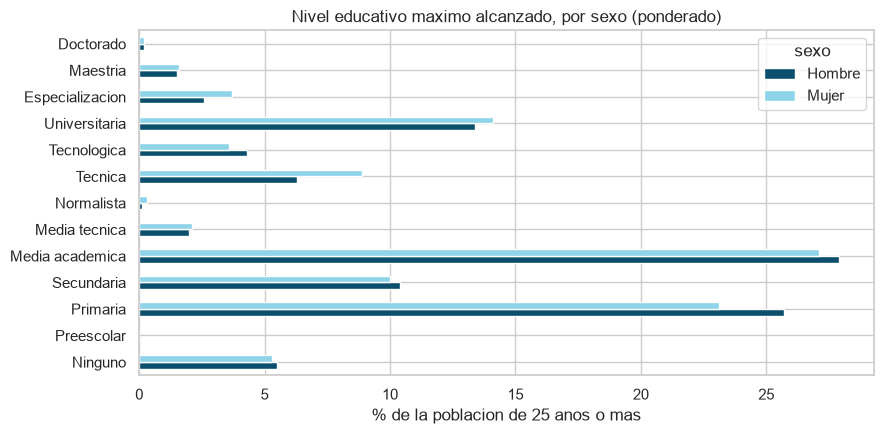

sexo,Hombre,Mujer
nivel_educativo,,
Ninguno,5.50,5.30
Preescolar,0.00,0.00
Primaria,25.70,23.10
Secundaria,10.40,10.00
Media academica,27.90,27.10
Media tecnica,2.00,2.10
Normalista,0.10,0.30
Tecnica,6.30,8.90
Tecnologica,4.30,3.60


In [44]:
adultos = df[(df.edad >= 25) & df.nivel_educativo.notna()]
tabla = pd.pivot_table(adultos, index="nivel_educativo", columns="sexo", values="fex", aggfunc="sum", observed=True)
tabla_pct = (tabla / tabla.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
tabla_pct.plot.barh(ax=ax, color=[AZUL, CELESTE])
ax.set_xlabel("% de la poblacion de 25 anos o mas"); ax.set_ylabel("")
ax.set_title("Nivel educativo maximo alcanzado, por sexo (ponderado)")
plt.tight_layout(); plt.show()
tabla_pct

### Agregaciones multiples y nombres claros

`agg` con tuplas `(columna, funcion)` permite construir un resumen con varias metricas y nombres legibles en una pasada. Aqui un perfil por posicion ocupacional: cuantos son (ponderado), mediana de ingreso, mediana de horas y tasa de cotizacion a pension.

In [45]:
perfil = (ocup.groupby("posicion_ocupacional", observed=True)
              .agg(poblacion=("fex", "sum"),
                   ingreso_mediano=("ingreso_laboral", "median"),
                   horas_medianas=("horas_semana", "median"),
                   pct_cotiza=("cotiza_pension", lambda s: (s == "Si").mean() * 100))
              .sort_values("poblacion", ascending=False))
perfil["poblacion"] = perfil.poblacion.round(0)
perfil.round(1)

,poblacion,ingreso_mediano,horas_medianas,pct_cotiza
posicion_ocupacional,,,,
Empleado particular,"10,644,994.00","1,426,000.00",47.00,69.90
Cuenta propia,"9,691,517.00","900,000.00",40.00,15.70
Empleado del gobierno,"909,422.00","3,850,000.00",40.00,93.30
Sin remuneracion otras empresas,"846,247.00","1,200,000.00",48.00,16.40
Empleado domestico,"719,312.00","900,000.00",46.00,14.70
Patron/empleador,"551,139.00","2,400,000.00",48.00,36.50
Familiar sin remuneracion,"382,860.00",NaN,30.00,2.60
Jornalero/peon,"7,462.00","800,000.00",40.00,0.00


<div style="background:#FDECEA;border-left:6px solid #B3261E;border-radius:8px;padding:14px 18px;margin:16px 0;">
  <b style="color:#7A1A12;">El error mas costoso con encuestas</b><br>
  <span style="color:#1A1A1A;font-size:14px;">Publicar una cifra calculada con <code>.mean()</code> o <code>.count()</code> sobre datos de la GEIH y llamarla "tasa nacional". Siempre que una tabla salga de una encuesta, pregunta: <b>use el factor de expansion?</b> Y cuando la desagregacion sea muy fina (un municipio, un grupo etnico pequeno), revisa cuantos <b>encuestados</b> hay detras: con 20 filas, el factor de expansion no convierte ruido en informacion.</span>
</div>

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 7</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Normalizacion, escalado y logaritmos</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Como hacer comparables variables que viven en magnitudes distintas.</div>
</div>

La edad va de 0 a 100; el ingreso de 0 a 100.000.000. Cualquier tecnica que **mida distancias o sume variables** (KNN, k-means, regresion regularizada, redes neuronales, un indice compuesto) va a quedar dominada por la de mayor magnitud. **Escalar** pone todas en un rango comparable. Tres tecnicas, cada una con su caso de uso:

| Tecnica | Formula | Resultado | Usar cuando |
|---|---|---|---|
| **Min-Max** | `(x - min) / (max - min)` | Entre 0 y 1 | Necesitas un rango acotado (redes neuronales, indices). Sensible a atipicos: un solo extremo aplasta al resto cerca de 0. |
| **Estandarizacion (z-score)** | `(x - media) / desv` | Media 0, desv 1 | Lo mas habitual para modelos lineales y distancias. Sensible a atipicos, pero menos que Min-Max. |
| **Robusta** | `(x - mediana) / IQR` | Mediana 0, IQR 1 | Hay atipicos y no quieres que manden. |

Nota importante: **escalar no cambia la forma** de la distribucion. Un ingreso sesgado sigue sesgado despues de estandarizar; solo cambian las unidades del eje.

In [46]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

x = ocup[["ingreso_laboral", "horas_semana", "edad"]].dropna()

escalas = {
    "Original":    x,
    "Min-Max":     pd.DataFrame(MinMaxScaler().fit_transform(x),   columns=x.columns, index=x.index),
    "Estandar":    pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index),
    "Robusta":     pd.DataFrame(RobustScaler().fit_transform(x),   columns=x.columns, index=x.index),
}
pd.concat({k: v.describe().loc[["mean", "std", "min", "50%", "max"]] for k, v in escalas.items()}, axis=0).round(3)

ingreso_laboral  horas_semana  edad
Original mean     1,794,945.65         44.01 41.80
         std      2,460,271.99         12.51 14.08
         min              0.00          1.00 15.00
         50%      1,423,500.00         46.00 41.00
         max    100,000,000.00        130.00 92.00
Min-Max  mean             0.02          0.33  0.35
         std              0.03          0.10  0.18
         min              0.00          0.00  0.00
         50%              0.01          0.35  0.34
         max              1.00          1.00  1.00
Estandar mean            -0.00          0.00  0.00
         std              1.00          1.00  1.00
         min             -0.73         -3.44 -1.90
         50%             -0.15          0.16 -0.06
         max             39.92          6.88  3.57
Robusta  mean             0.31         -0.25  0.04
         std              2.05          1.56  0.64
         min             -1.19         -5.62 -1.18
         50%              0.00          0.00  0.00
         max             82.15         10.50  2.32

Lo que muestra la tabla: con **Min-Max** la mediana del ingreso queda en 0,09 porque el maximo (un valor extremo) estira el rango y comprime al 99% de la gente en el primer decimo. Con **estandarizacion** la mediana queda negativa, porque la media esta por encima de ella. Con **robusta** la mediana es exactamente 0 y el 50% central cabe entre -0,5 y 0,5, sin importar los extremos.

Hagamoslo a mano una vez para que no sea magia, y comprobemos que coincide con scikit-learn.

In [47]:
s = x.ingreso_laboral
manual = pd.DataFrame({
    "minmax_manual":  (s - s.min()) / (s.max() - s.min()),
    "z_manual":       (s - s.mean()) / s.std(ddof=0),          # sklearn usa ddof=0
    "robusta_manual": (s - s.median()) / (s.quantile(0.75) - s.quantile(0.25)),
})
sklearn_cols = pd.DataFrame({
    "minmax_sklearn":  escalas["Min-Max"].ingreso_laboral,
    "z_sklearn":       escalas["Estandar"].ingreso_laboral,
    "robusta_sklearn": escalas["Robusta"].ingreso_laboral,
})
print("Max diferencia manual vs sklearn:", np.abs(manual.values - sklearn_cols.values).max())

Max diferencia manual vs sklearn: 1.1102230246251565e-16


<div style="background:#E6F4EA;border-left:6px solid #1E7B34;border-radius:8px;padding:14px 18px;margin:16px 0;">
  <b style="color:#145223;">Ajustar en entrenamiento, aplicar en todo</b><br>
  <span style="color:#1A1A1A;font-size:14px;">Cuando escales para un modelo, calcula los parametros (min, max, media, desv) <b>solo con los datos de entrenamiento</b> (<code>fit</code>) y aplicalos a los de prueba (<code>transform</code>). Si ajustas con todo, el modelo "ve" informacion del futuro y tus metricas mienten. Es lo que se llama <i>fuga de datos</i> (data leakage).</span>
</div>

### La escala logaritmica

El ingreso, los precios, la poblacion de las ciudades, el tamano de las empresas: muchas variables economicas son **multiplicativas**. Pasar de 1 a 2 millones es "duplicar", igual que pasar de 10 a 20. En una escala lineal esas dos diferencias se ven como 1 y 10 millones; en escala logaritmica se ven iguales, porque `log(2x) - log(x) = log(2)` sin importar `x`.

Consecuencias practicas del logaritmo:

1. **Comprime la cola derecha** y convierte una distribucion sesgada en una aproximadamente simetrica: los metodos que suponen normalidad vuelven a funcionar.
2. **Los atipicos dejan de dominar**: 100 millones pasa a ser 18,4 y 1 millon a ser 13,8. La distancia se vuelve razonable.
3. **Diferencias en log ≈ diferencias porcentuales**: una diferencia de 0,10 en log es ~10% mas. Por eso las brechas salariales se calculan en log.

Se usa `np.log1p(x) = log(1 + x)` en vez de `np.log(x)` para que el cero no de `-inf`. Para volver a pesos: `np.expm1`.

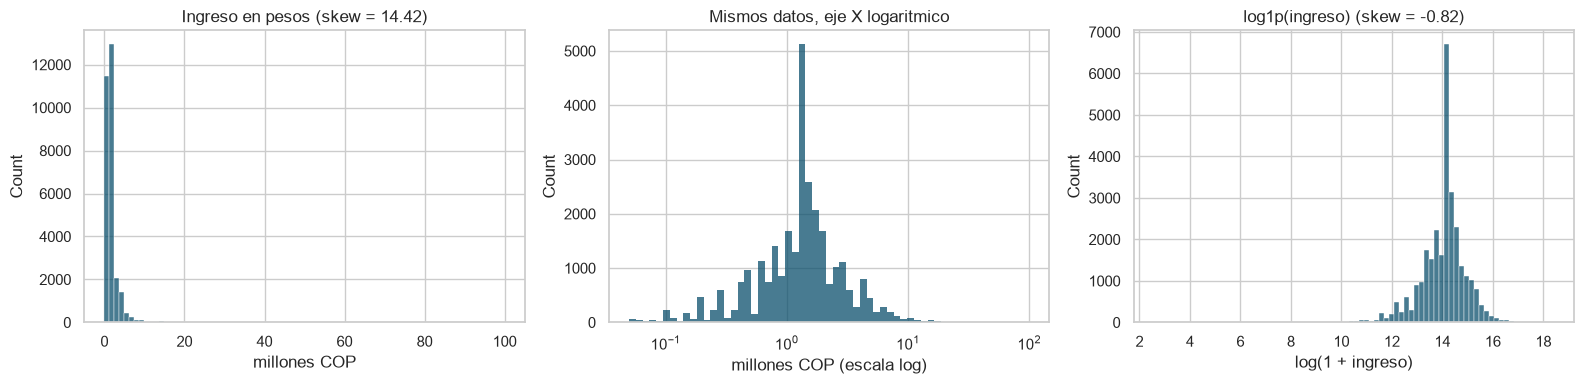

In [48]:
ing_ocup = ocup.ingreso_laboral.dropna()
ing_ocup = ing_ocup[ing_ocup > 0]
log_ing = np.log1p(ing_ocup)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(ing_ocup / 1e6, bins=80, ax=axes[0], color=AZUL)
axes[0].set_title(f"Ingreso en pesos (skew = {ing_ocup.skew():.2f})"); axes[0].set_xlabel("millones COP")

sns.histplot(ing_ocup / 1e6, bins=np.logspace(np.log10(0.05), np.log10(100), 60), ax=axes[1], color=AZUL)
axes[1].set_xscale("log"); axes[1].set_title("Mismos datos, eje X logaritmico"); axes[1].set_xlabel("millones COP (escala log)")

sns.histplot(log_ing, bins=80, ax=axes[2], color=AZUL)
axes[2].set_title(f"log1p(ingreso) (skew = {log_ing.skew():.2f})"); axes[2].set_xlabel("log(1 + ingreso)")
plt.tight_layout(); plt.show()

Los paneles 2 y 3 muestran lo mismo de dos formas: en el 2 cambiamos el **eje** (los datos siguen en pesos, util para graficar); en el 3 cambiamos los **datos** (util para modelar). La asimetria pasa de ~5 a cerca de 0.

Un uso directo: la **brecha salarial por sexo**. Mira primero las medianas en pesos: son **identicas**, y no por casualidad: 1.423.500 es exactamente el **salario minimo de 2025**, y tanta gente gana justo eso que la mediana de ambos sexos cae ahi. La mediana, por construccion, no ve la brecha. La media en pesos si la ve, pero la arrastran los extremos. La diferencia de medias **en log** es el punto medio honesto: se interpreta, aproximadamente, como diferencia porcentual y no la dominan los 100 millones de nadie.

In [49]:
ocup_pos = ocup[ocup.ingreso_laboral > 0].copy()
ocup_pos["log_ingreso"] = np.log1p(ocup_pos.ingreso_laboral)

brecha = ocup_pos.groupby("sexo", observed=True).agg(media_pesos=("ingreso_laboral", "mean"),
                                                     mediana_pesos=("ingreso_laboral", "median"),
                                                     media_log=("log_ingreso", "mean"))
dif_log = brecha.loc["Hombre", "media_log"] - brecha.loc["Mujer", "media_log"]
display(brecha.round(3))
print(f"Diferencia en log: {dif_log:.3f}  ->  los hombres ganan en promedio ~{(np.exp(dif_log) - 1) * 100:.1f}% mas (media geometrica)")
print(f"Con medianas en pesos la brecha seria: {(brecha.loc['Hombre','mediana_pesos'] / brecha.loc['Mujer','mediana_pesos'] - 1) * 100:.1f}%  (ambas medianas = salario minimo)")
print(f"Con medias en pesos: {(brecha.loc['Hombre','media_pesos'] / brecha.loc['Mujer','media_pesos'] - 1) * 100:.1f}%")

,media_pesos,mediana_pesos,media_log
sexo,,,
Hombre,"1,884,374.70","1,423,500.00",14.12
Mujer,"1,709,224.75","1,423,500.00",13.93


Diferencia en log: 0.187  ->  los hombres ganan en promedio ~20.6% mas (media geometrica)
Con medianas en pesos la brecha seria: 0.0%  (ambas medianas = salario minimo)
Con medias en pesos: 10.2%


### Mas alla del logaritmo: Box-Cox y Yeo-Johnson

El logaritmo es un caso particular de una familia de transformaciones de potencia. `PowerTransformer` de scikit-learn **busca el exponente que mas acerca la variable a una normal**. Box-Cox exige valores positivos; Yeo-Johnson acepta ceros y negativos. Sirve cuando el log se queda corto o se pasa. Lo mostramos por completitud; en la practica, con ingresos, el log casi siempre basta y es mas interpretable.

In [50]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
yj = pt.fit_transform(ing_ocup.to_frame()).ravel()
print(f"Lambda encontrado: {pt.lambdas_[0]:.3f}  (lambda = 0 equivale exactamente al logaritmo)")
print(f"Skew original: {ing_ocup.skew():.2f} | log1p: {log_ing.skew():.2f} | Yeo-Johnson: {pd.Series(yj).skew():.2f}")

Lambda encontrado: 0.152  (lambda = 0 equivale exactamente al logaritmo)
Skew original: 14.42 | log1p: -0.82 | Yeo-Johnson: 0.09


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 8</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Discretizacion y codificacion</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Numeros que se vuelven categorias, y categorias que se vuelven numeros.</div>
</div>

### Discretizar: de numero a rango

A veces una variable continua se comunica mejor por tramos: "jovenes de 18 a 28", "quintil 1 de ingreso". Dos herramientas:

- `pd.cut`: cortes en **valores** que tu defines (rangos de edad con sentido de politica publica).
- `pd.qcut`: cortes en **cuantiles**, cada grupo con el mismo numero de filas (quintiles, deciles).

Regla: los rangos de `cut` salen del **dominio** (la edad laboral empieza a los 15; la pension a los 57/62), no del dataset.

In [51]:
df["rango_edad"] = pd.cut(df.edad, bins=[-1, 14, 28, 40, 59, 200],
                          labels=["0-14 (ninez)", "15-28 (juventud)", "29-40", "41-59", "60+"])

quintiles = pd.qcut(ocup.ingreso_laboral, q=5, labels=["Q1 (20% mas bajo)", "Q2", "Q3", "Q4", "Q5 (20% mas alto)"])
df.loc[ocup.index, "quintil_ingreso"] = quintiles

print(df.rango_edad.value_counts(sort=False)); print()
print("Limites de los quintiles de ingreso:")
print(pd.qcut(ocup.ingreso_laboral, q=5).cat.categories)

rango_edad
0-14 (ninez)        13406
15-28 (juventud)    14561
29-40               11384
41-59               15758
60+                 12747
Name: count, dtype: int64

Limites de los quintiles de ingreso:
IntervalIndex([(-0.001, 700000.0], (700000.0, 1270000.0], (1270000.0, 1500000.0], (1500000.0, 2200000.0], (2200000.0, 100000000.0]], dtype='interval[float64, right]')


In [52]:
tabla = pd.crosstab(df.rango_edad, df.quintil_ingreso, values=df.fex, aggfunc="sum", normalize="index") * 100
tabla.round(1)

quintil_ingreso,Q1 (20% mas bajo),Q2,Q3,Q4,Q5 (20% mas alto)
rango_edad,,,,,
15-28 (juventud),20.70,18.60,27.30,21.20,12.20
29-40,15.20,15.40,23.80,20.30,25.40
41-59,21.20,18.20,19.90,18.90,21.70
60+,42.10,21.70,12.80,10.20,13.20


### Codificar: de categoria a numero

Los modelos no entienden "Universitaria". Dos formas de traducir, y elegir mal distorsiona el resultado:

- **Codificacion ordinal**: un entero por categoria, **solo si hay orden** (nivel educativo: 0 < 1 < 2...). Si la variable no es ordinal (departamento), asignarle enteros le inventa un orden falso.
- **One-hot** (`pd.get_dummies`): una columna binaria por categoria. Correcto para nominales. Crea muchas columnas si hay muchas categorias (33 departamentos → 33 columnas); `drop_first=True` elimina una redundante para modelos lineales.

In [53]:
# Ordinal: pandas ya conoce el orden porque la definimos como Categorical ordenada
df["nivel_educativo_cod"] = df.nivel_educativo.cat.codes.replace(-1, np.nan)

# One-hot para nominales
dummies = pd.get_dummies(df[["sexo", "clase", "regimen_salud"]], prefix=["sexo", "clase", "reg"], dtype=int)

print(df[["nivel_educativo", "nivel_educativo_cod"]].drop_duplicates().sort_values("nivel_educativo_cod").to_string(index=False))
dummies.head()

nivel_educativo  nivel_educativo_cod
        Ninguno                 0.00
     Preescolar                 1.00
       Primaria                 2.00
     Secundaria                 3.00
Media academica                 4.00
  Media tecnica                 5.00
     Normalista                 6.00
        Tecnica                 7.00
    Tecnologica                 8.00
  Universitaria                 9.00
Especializacion                10.00
       Maestria                11.00
      Doctorado                12.00
            NaN                  NaN


,sexo_Hombre,sexo_Mujer,clase_Cabecera,clase_Rural,reg_Contributivo,reg_Especial,reg_Subsidiado
0,0,1,0,1,0,0,1
1,1,0,0,1,0,0,1
2,1,0,0,1,0,0,1
3,1,0,0,1,0,0,1
4,0,1,0,1,0,0,1


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 9</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Pipeline reproducible</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Todo lo anterior en una funcion que cualquiera pueda correr el mes que viene con el archivo nuevo.</div>
</div>

La limpieza que vive en 40 celdas sueltas no es reproducible: nadie sabe en que orden correrlas ni que cambio cada una. El cierre del trabajo es **empaquetar los pasos en una funcion** que recibe el archivo crudo y devuelve la tabla limpia **y un reporte** de lo que hizo. Tres principios:

1. **No modificar la entrada**: trabaja sobre una copia.
2. **Cada paso registra su efecto**: cuantas filas, cuantos nulos, cuantos reemplazos.
3. **Los parametros van afuera**: el diccionario, los centinelas, los umbrales. Asi el mes que viene cambias un numero, no el codigo.

In [54]:
def limpiar_geih(crudo, diccionario, etiquetas, centinelas, departamentos, p_wins=(0.01, 0.99), max_horas=84):
    log = []
    d = crudo.rename(columns=dict(zip(diccionario.codigo, diccionario.nombre))).copy()
    log.append(f"Entrada: {d.shape[0]:,} filas x {d.shape[1]} columnas")

    # 1. duplicados
    n0 = len(d)
    d = d.drop_duplicates().drop_duplicates(subset=["directorio", "secuencia_p", "orden"], keep="first")
    log.append(f"Duplicados eliminados: {n0 - len(d):,}")

    # 2. centinelas -> NaN
    for col, codigos in centinelas.items():
        n = d[col].isin(codigos).sum()
        d[col] = d[col].replace(codigos, np.nan)
        log.append(f"Centinelas {codigos} en {col} -> NaN: {n:,}")

    # 3. codigos -> etiquetas
    for col, mapa in etiquetas.items():
        d[col] = d[col].map(mapa).astype("category")
    d["nivel_educativo"] = pd.Categorical(d.nivel_educativo, categories=orden_educ, ordered=True)
    d["departamento"] = d.dpto.map(departamentos).astype("category")
    log.append(f"Columnas etiquetadas: {len(etiquetas) + 1}")

    # 4. reglas de validacion
    d["flag_horas_sospechosas"] = d.horas_semana > max_horas
    imposible = d.meses_trabajo > (d.edad - 10) * 12
    d.loc[imposible, "meses_trabajo"] = np.nan
    log.append(f"Horas > {max_horas} marcadas: {d.flag_horas_sospechosas.sum():,} | antiguedad imposible anulada: {imposible.sum():,}")

    # 5. atipicos de ingreso: marcar (MAD) + winsorizar en columna nueva
    ocu = d.posicion_ocupacional.notna() & (d.ingreso_laboral > 0)
    mask, _ = atipicos_mad(d.loc[ocu, "ingreso_laboral"])
    d["flag_ingreso_atipico"] = False
    d.loc[mask.index[mask], "flag_ingreso_atipico"] = True
    lo, hi = d.loc[ocu, "ingreso_laboral"].quantile(p_wins)
    d["ingreso_wins"] = d.ingreso_laboral.clip(lo, hi)
    log.append(f"Ingresos atipicos (MAD) marcados: {mask.sum():,} | winsorizado en p{int(p_wins[0]*100)}-p{int(p_wins[1]*100)}")

    # 6. imputacion de faltantes reales de ingreso con mediana por grupo + bandera
    sin_rem = d.posicion_ocupacional.isin(["Familiar sin remuneracion", "Sin remuneracion otras empresas"])
    falta = d.posicion_ocupacional.notna() & d.ingreso_laboral.isna() & ~sin_rem
    d["ingreso_imputado"] = falta
    med = d.groupby(["sexo", "nivel_educativo", "posicion_ocupacional"], observed=True).ingreso_laboral.transform("median")
    d.loc[falta, "ingreso_laboral"] = med[falta].fillna(d.ingreso_laboral.median())
    log.append(f"Ingresos imputados (mediana por grupo): {falta.sum():,} | sin remuneracion dejados en NaN: {(sin_rem & d.ingreso_laboral.isna()).sum():,}")

    # 7. derivadas
    d["log_ingreso"] = np.log1p(d.ingreso_laboral)
    d["rango_edad"] = pd.cut(d.edad, bins=[-1, 14, 28, 40, 59, 200], labels=["0-14", "15-28", "29-40", "41-59", "60+"])
    log.append(f"Salida: {d.shape[0]:,} filas x {d.shape[1]} columnas")
    return d, log

limpio_final, log = limpiar_geih(crudo, diccionario, etiquetas, centinelas, departamentos)
print("\n".join(f"  - {l}" for l in log))

  - Entrada: 67,856 filas x 27 columnas
  - Duplicados eliminados: 0
  - Centinelas [9] en afiliado_salud -> NaN: 16
  - Centinelas [9] en regimen_salud -> NaN: 25
  - Centinelas [9] en campesino -> NaN: 142
  - Centinelas [99] en nivel_educativo -> NaN: 0
  - Columnas etiquetadas: 16
  - Horas > 84 marcadas: 112 | antiguedad imposible anulada: 5
  - Ingresos atipicos (MAD) marcados: 1,719 | winsorizado en p1-p99
  - Ingresos imputados (mediana por grupo): 159 | sin remuneracion dejados en NaN: 455
  - Salida: 67,856 filas x 34 columnas


Y exportamos. **Parquet** conserva los tipos (`category`, fechas) y pesa una fraccion del CSV; **CSV** sirve para compartir con quien no use Python. Guardar ambos es habitual.

In [55]:
limpio_final.to_parquet("geih_2025_06_limpio.parquet", index=False)
limpio_final.to_csv("geih_2025_06_limpio.csv", index=False)

print("Tamano CSV:    ", f"{os.path.getsize('geih_2025_06_limpio.csv') / 1e6:.1f} MB")
print("Tamano Parquet:", f"{os.path.getsize('geih_2025_06_limpio.parquet') / 1e6:.1f} MB")

Tamano CSV:     14.6 MB
Tamano Parquet: 1.2 MB


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 10</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Errores tipicos y checklist</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Lo que revisar antes de decir 'los datos estan limpios'.</div>
</div>

### Errores tipicos

| Error | Por que pasa | Como evitarlo |
|---|---|---|
| Imputar un faltante estructural | No se cruzo el nulo con la variable de flujo | Pregunta "aplicaba?" antes de imputar. Seccion 2. |
| Promediar un codigo (`dpto.mean()`) | La columna es numerica aunque sea categorica | Etiqueta y convierte a `category` al inicio. |
| Dejar el `9` de "no sabe" | Parece un dato | Lista los centinelas del diccionario y conviertelos a `NaN`. |
| Eliminar atipicos por reflejo | "Danan el promedio" | Juzga en contexto; prefiere marcar, winsorizar o log. |
| Usar z-score con datos sesgados | Es el que ensenan primero | IQR o MAD cuando la distribucion tiene cola. |
| Imputar con la media bajo MAR | Es lo mas facil | Imputa por grupo o con modelo usando las variables que explican el faltante. |
| `count()` y `mean()` en una encuesta | Olvidar el diseno muestral | Suma `fex` y usa promedios ponderados. Seccion 6. |
| Escalar con todo el dataset antes de dividir | Conveniencia | `fit` con entrenamiento, `transform` con el resto. |
| One-hot a una ordinal, o enteros a una nominal | Confundir tipos de categorica | Ordinal → codigos con orden; nominal → one-hot. |
| Limpieza en celdas sueltas | Prisa | Funcion + reporte. Seccion 9. |

### Checklist de limpieza

Antes de entregar cualquier tabla como "limpia", revisa que puedes responder **si** a todo:

- [ ] Se que significa cada columna y tengo el diccionario como datos.
- [ ] Cada columna tiene el tipo correcto (numerica, categoria, ordinal, fecha).
- [ ] Para cada columna con nulos se si son estructurales o reales, y lo documente.
- [ ] Busque y converti los valores centinela.
- [ ] La llave primaria es unica; los duplicados se resolvieron con una regla explicita.
- [ ] Escribi reglas de validacion de dominio y revise las violaciones una por una.
- [ ] Detecte atipicos con un metodo adecuado a la distribucion y decidi su tratamiento **en contexto**.
- [ ] Lo imputado esta marcado con una bandera y se cuantas celdas fueron.
- [ ] Las agregaciones usan el factor de expansion.
- [ ] Las transformaciones (log, escalas) estan en columnas nuevas; el original sigue intacto.
- [ ] Todo esta en una funcion que devuelve la tabla limpia y un reporte.

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 11</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Ejercicios</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Sin soluciones. Usa el dataset del notebook.</div>
</div>

Trabaja sobre `limpio_final` (o vuelve a correr `limpiar_geih` si lo danaste). Para cada ejercicio escribe el codigo **y una frase** con la conclusion.

**1. Nulos.** La columna `regimen_salud` tiene ~3% de nulos. Determina que parte es estructural (personas no afiliadas) y que parte es real. Cuantos faltantes reales hay?

**2. Reglas.** Agrega a `validar()` dos reglas nuevas que vengan de tu conocimiento del dominio (por ejemplo, sobre `estudia` y `edad`, o sobre `cotiza_pension` y `posicion_ocupacional`) y reporta cuantas filas las violan.

**3. Atipicos.** Aplica IQR, z-score y MAD a `horas_semana` entre los ocupados. Compara cuantos marca cada metodo con los 112 que ya marcaste por la regla de 84 horas. Cual metodo se acerca mas al criterio fisico?

**4. Atipicos por grupo.** Los atipicos de ingreso se detectaron sobre todos los ocupados juntos. Repite la deteccion MAD **dentro de cada posicion ocupacional** (`groupby().transform`). Cambia mucho el conjunto de personas marcadas? Por que?

**5. Imputacion.** Repite el experimento MCAR borrando el **30%** de `ingreso_laboral` en vez del 15%. Como cambia el MAE de cada metodo? Y la `razon_desv`?

**6. Imputacion MNAR.** Disena una funcion `borrar_mnar` que borre el ingreso con probabilidad creciente **en el propio ingreso** (los que mas ganan no responden). Corre los cinco metodos. Alguno corrige el sesgo? Explica por que no.

**7. Agregacion.** Calcula, con factor de expansion, el ingreso laboral mediano por departamento. (Pista: la mediana ponderada no existe en pandas; implementala ordenando por ingreso y acumulando `fex` hasta el 50%.) Que departamentos estan en los extremos?

**8. Agregacion.** Construye una tabla con la tasa de cotizacion a pension (ponderada) por `rango_edad` x `sexo`. Hay alguna celda con menos de 30 encuestados detras? Que harias con ella?

**9. Escalas.** Calcula la brecha de ingreso en log entre `Cabecera` y `Rural`, y por separado dentro de cada nivel educativo. La brecha se mantiene al controlar por educacion?

**10. Pipeline.** Modifica `limpiar_geih` para que acepte un parametro `metodo_imputacion` con opciones `"mediana"`, `"grupo"` y `"knn"`. Comprueba que el reporte refleja la opcion elegida.

**Reto integrador.** Descarga otro mes de la GEIH 2025 desde el portal de microdatos del DANE (`microdatos.dane.gov.co`, catalogo "GEIH 2025"), construye el mismo archivo (modulo Personas + las 6 variables de Ocupados unidas por `DIRECTORIO`, `SECUENCIA_P`, `ORDEN`), pasalo por `limpiar_geih` **sin cambiar el codigo** y compara el reporte con el de junio. Que cambio? Que no cambio? Que te dice eso sobre la reproducibilidad de tu pipeline?

---
## Referencias

- DANE. *Gran Encuesta Integrada de Hogares - GEIH 2025*. Microdatos y diccionarios: https://microdatos.dane.gov.co/index.php/catalog/853
- DANE. *GEIH: Factores de expansion y diseno muestral* (documentacion metodologica del mismo catalogo).
- McKinney, W. *Python for Data Analysis*, 3a ed. Cap. 7 "Data Cleaning and Preparation".
- van Buuren, S. *Flexible Imputation of Missing Data*, 2a ed. (libre en linea: stefvanbuuren.name/fimd). Referencia para MCAR/MAR/MNAR e imputacion multiple.
- Leys, C. et al. (2013). *Detecting outliers: Do not use standard deviation around the mean, use absolute deviation around the median*. J. Exp. Social Psychology.
- scikit-learn. *Imputation of missing values* y *Preprocessing data* (guia de usuario).

<div style="background:#0B4F6C;border-radius:12px;padding:20px 24px;margin-top:24px;">
  <div style="color:#8FD3E8;font-size:12px;letter-spacing:4px;font-weight:700;">DATAXPERIENCE</div>
  <div style="color:#FFFFFF;font-size:15px;margin-top:6px;">Fin del notebook 05. Siguiente: <b>06 - Taller de limpieza de datos</b>, sobre el mismo dataset.</div>
</div>